# 03 — NMF em Tweets BR Eleições 2022 (PT-BR)

## O que esse notebook faz

Aplica **Non-negative Matrix Factorization (NMF)**, via `gensim.models.Nmf`, ao corpus de tweets das eleições brasileiras 2022. Segue a mesma estrutura de pipeline do `03_nmf_folha.ipynb` e do `02_lda_tweets_bre2022.ipynb`, com adaptações para texto curto/informal.

**Corpus:** Tweets BR 2022 — ~200k tweets PT-BR, texto curto (~23 tokens), discurso político.

**Hipótese H2:** assim como no LDA, espera-se que NMF em texto curto/informal degrade vs corpus formal — este notebook documenta empiricamente esse comportamento para o NMF.


## 1. Setup e imports

Carregamos parâmetros do `configs/params.yaml` (entrada `corpora.tweets_bre2022`), o seed global e as funções dos pipelines reusáveis:

- `_helpers.lemmatize_corpus(docs, lang, params, model_key="nmf")` → tokens lematizados + Dictionary com filter_extremes (bloco `nmf:`)
- `_helpers.grid_search_k_nmf / grid_search_nmf_hparams / train_nmf / extract_topics_keywords / compute_doc_distributions` → fit e extração
- `_helpers.name_all_topics` → rotulagem via Ollama (modelo em `params.yaml`)
- `_helpers.*` → métricas (c_v, exclusivity, FREX, NPMI, etc.) — compartilhadas com o LDA


In [1]:
# ── path fix: resolve _helpers.py e data/ de qualquer subdiretório ──
import sys as _sys, os as _os
from pathlib import Path as _P
_here = _P().resolve()
_nb_dir = _here if (_here / '_helpers.py').exists() else _here.parent
if str(_nb_dir) not in _sys.path:
    _sys.path.insert(0, str(_nb_dir))
_os.chdir(_nb_dir)          # '../data/...' paths ficam corretos
del _here, _nb_dir, _P, _sys, _os
# ─────────────────────────────────────────────────────────────────────
# Cell 1 — Imports
import sys, os, json, time, ast
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
from gensim.models import Nmf

from _helpers import load_params, get_corpus_config, get_seed, load_corpus
from _helpers import lemmatize_corpus
from _helpers import (
    grid_search_k_nmf, grid_search_nmf_hparams, train_nmf, extract_topics_keywords,
    compute_doc_distributions, qualitative_report,
    compute_nmf_reconstruction_error, cache_protocolo_apto,
)
from _helpers import name_all_topics
from _helpers import (
    compute_coherence_cv, compute_exclusivity, compute_exclusivity_ctfidf, compute_diversity,
    compute_topic_diversity, compute_frex_score, compute_stability, export_results, export_topics_for_eval,
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

D:\Área de Trabalho\UPE\1 Período\PLN\Topic Modeling - LDA and BERTopic\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Cell 2 — Carrega params do params.yaml
CORPUS_ID = "tweets_bre2022"
LANG = "pt"

params = load_params()
_, cfg = get_corpus_config(params, CORPUS_ID)
seed = get_seed(params)
TEXT_COL = cfg["text_column"]

print(f"corpus_id = {CORPUS_ID}")
print(f"text_column = {TEXT_COL}")
print(f"language = {LANG}")
print(f"seed = {seed}")
print(f"covariates (usadas no STM, não no NMF) = {cfg.get('covariates', [])}")


corpus_id = tweets_bre2022
text_column = message
language = pt
seed = 42
covariates (usadas no STM, não no NMF) = ['category']


## 2. Corpus Tweets BR Eleições 2022

### Origem e schema

- Dataset de tweets em PT-BR sobre as eleições brasileiras de 2022 (Zenodo 14834749)
- Filtros aplicados: `len(message.split()) >= 20` é relaxado aqui — texto curto é a própria característica do corpus (~23 tokens/doc em média)
- Schema padronizado: `post_id, message, date, category, lang`

### Limitações

- **`category` não é categoria temática**: por construção do corpus, este campo é um proxy temporal (`YYYY-MM`, mês de coleta), não um rótulo de assunto. Ver `covariates: [category]` em `params.yaml` — usado no STM como controle temporal, não como ground-truth de tópico.
- **Texto curto/informal (H2)**: tweets têm vocabulário muito mais esparso que corpus formal (Folha), o que tende a degradar a coerência c_v — assim como documentado no LDA, este notebook verifica empiricamente esse efeito para o NMF.


In [3]:
# Cell 3 — Carrega corpus_limpo.csv (latest-wins: le diretamente do output do 01-preprocessing)
from _helpers import resolve_latest_dir

_corpus_base = Path(f"../../01-preprocessing/data/output/{CORPUS_ID}")
_corpus_dir  = resolve_latest_dir(
    _corpus_base,
    contains="corpus_limpo.csv",
    fallback_dir=Path(f"../data/input/{CORPUS_ID}"),
)
print(f"Versao do corpus: {_corpus_dir.name}")

df = load_corpus(str(_corpus_dir) + "/")
docs     = df[TEXT_COL].astype(str).tolist()
post_ids = df["post_id"].astype(str).tolist()

print(f"Total docs: {len(docs):,}")
print(f"Colunas: {list(df.columns)}")
df.head(3)


  versão resolvida: tweets_bre2022_20260629_215159/ (latest)
Versao do corpus: tweets_bre2022_20260629_215159
Carregado: corpus_limpo.csv (8811 docs, SEM coluna 'sentiment' — rode 03-sentiment antes para ter cruzamento topic x sentiment automatico)
Total docs: 8,811
Colunas: ['tweet_id', 'message', 'message_raw', 'post_id', 'data', 'user', 'user_info', 'has_mention', 'mentions', 'is_reply', 'reply_to', 'is_quote', 'quoted_from', 'is_retweet', 'retweeted_from', 'hashtags', 'native_mentions', 'retweet_mentions', 'Unnamed: 0', 'platform', 'election', 'category']


,tweet_id,message,message_raw,post_id,data,user,user_info,has_mention,mentions,is_reply,...,quoted_from,is_retweet,retweeted_from,hashtags,native_mentions,retweet_mentions,Unnamed: 0,platform,election,category
0,1562979518280699904,"@LulaOficial “Lulinha”, “Alckmin”, “Paulo Frei...","@LulaOficial “Lulinha”, “Alckmin”, “Paulo Frei...",tw_00044339,2022-08-26 01:45:30,luciana_onofre,"{'id': 2853238599, 'name': 'Luciana Lula da Si...",True,"[{'id': '2670726740', 'username': 'LulaOficial'}]",False,...,NaN,True,"{'user': 'UOLNoticias', 'user_id': 14594698, '...","['#LADRAONOJN', '#LulaNoJN']",NaN,NaN,NaN,twitter,br_2022,2022-08
1,1562053466830389249,@jairbolsonaro @Anitta Bora da aquela pesquisa...,@jairbolsonaro @Anitta Bora da aquela pesquisa...,tw_00073680,2022-08-23 12:25:42,mafra_leoni,"{'id': 1479929106804482048, 'name': 'Leoni Gar...",True,"[{'id': '128372940', 'username': 'jairbolsonar...",False,...,NaN,True,"{'user': 'Jouberth19', 'user_id': 350476403, '...",['#GloboLixo'],NaN,NaN,NaN,twitter,br_2022,2022-08
2,1561862082315837440,Hoje eu tô muito Bonnerzete e Renatete! #Jorna...,Hoje eu tô muito Bonnerzete e Renatete! #Jorn...,tw_00102132,2022-08-22 23:45:13,vieradriano,"{'id': 1349339460027211777, 'name': 'Adrianno ...",False,NaN,False,...,NaN,True,"{'user': 'tvlizando', 'user_id': 2471757957, '...","['#JornalNacional', '#JN', '#ForaBolsonaro']",NaN,NaN,NaN,twitter,br_2022,2022-08


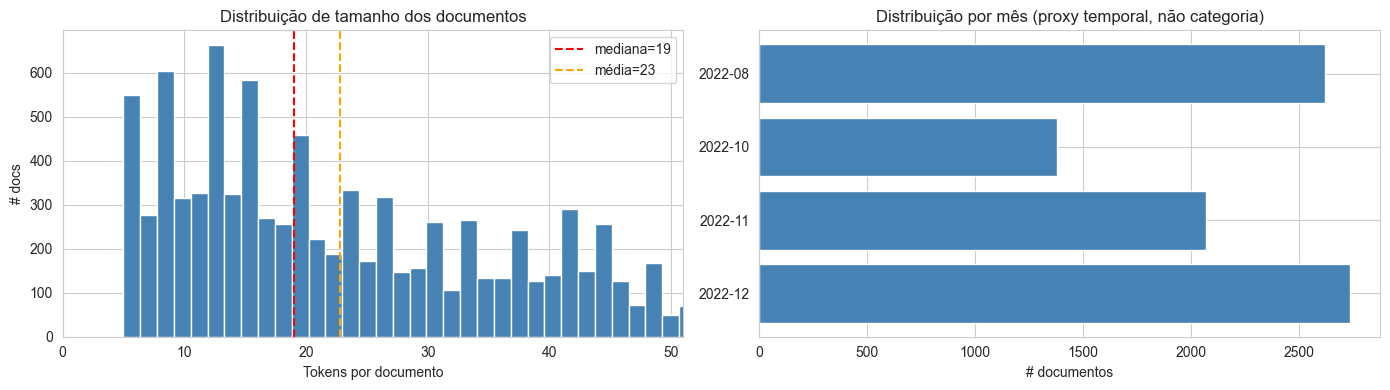


Descritivas n_tokens: {'count': 8811.0, 'mean': 22.75939166950403, 'std': 13.05769920589274, 'min': 5.0, '25%': 12.0, '50%': 19.0, '75%': 33.0, 'max': 88.0}


In [4]:
# Cell 4 — Estatisticas descritivas + distribuicao de tokens
df["n_tokens"] = df["message"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df["n_tokens"], bins=60, edgecolor="white", color="steelblue")
axes[0].axvline(df["n_tokens"].median(), color="red", linestyle="--", label=f'mediana={df["n_tokens"].median():.0f}')
axes[0].axvline(df["n_tokens"].mean(), color="orange", linestyle="--", label=f'média={df["n_tokens"].mean():.0f}')
axes[0].set_xlabel("Tokens por documento"); axes[0].set_ylabel("# docs")
axes[0].set_title("Distribuição de tamanho dos documentos"); axes[0].legend()
axes[0].set_xlim(0, df["n_tokens"].quantile(0.99))

cat_counts = df["category"].value_counts().sort_index()
axes[1].barh(cat_counts.index[::-1], cat_counts.values[::-1], color="steelblue")
axes[1].set_xlabel("# documentos"); axes[1].set_title("Distribuição por mês (proxy temporal, não categoria)")
plt.tight_layout(); plt.show()

print(f"\nDescritivas n_tokens: {df['n_tokens'].describe().to_dict()}")


## 3. Lematização e construção do vocabulário

### O que `_helpers.lemmatize_corpus` faz

1. Carrega spaCy `pt_core_news_lg` (cached em module-level)
2. Para cada doc: tokeniza, descarta stopwords (lista interna spaCy) + tokens não-alfa + tokens curtos (`len(lemma) <= 2`)
3. Constrói gensim `Dictionary` com `filter_extremes(no_below=5, no_above=0.5)` (parâmetros do bloco `nmf:` em `params.yaml`, via `model_key="nmf"`):
   - Remove palavras que aparecem em <5 docs (raras, ruído)
   - Remove palavras em >50% dos docs (genéricas, sem poder discriminante — ex.: "disse")

### Por que lematizar (vs stemming)

- Lematização preserva forma legível (`correndo` → `correr`; stemming agressivo produziria `corr`)
- Mais interpretável para a banca da dissertação
- Custo: ~30s a ~3min em CPU dependendo do volume
- Mesmo vocabulário do LDA (mesmos `no_below`/`no_above`) — garante comparabilidade direta entre os dois modelos


In [5]:
# Cell 5 — Lematiza corpus
print("Lematizando (single-process spaCy pt_core_news_lg)...")
t0 = time.time()
tokenized, dictionary = lemmatize_corpus(
    docs, LANG, params, model_key="nmf",
    extra_stopwords=cfg.get("nmf_stopwords_extra", []),
)
print(f"  done em {time.time()-t0:.0f}s")
print(f"  vocab final: {len(dictionary):,} palavras (após filter_extremes)")

# Estatísticas dos tokens lemmatizados
n_tokens_lemma = [len(t) for t in tokenized]
n_unique = [len(set(t)) for t in tokenized]

print(f"\n  avg tokens/doc após lemmatize: {np.mean(n_tokens_lemma):.1f}")
print(f"  avg unique tokens/doc: {np.mean(n_unique):.1f}")


Lematizando (single-process spaCy pt_core_news_lg)...


  done em 30s
  vocab final: 2,617 palavras (após filter_extremes)

  avg tokens/doc após lemmatize: 10.9
  avg unique tokens/doc: 10.4


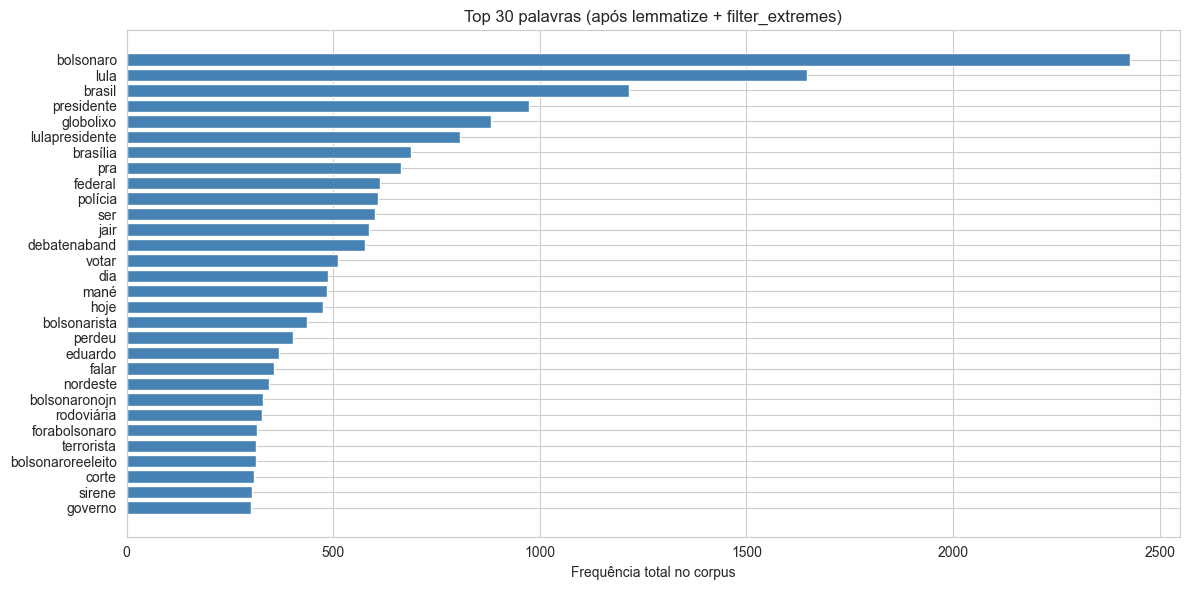

In [6]:
# Cell 6 — Top 30 palavras mais frequentes no vocabulário final
all_tokens = [t for doc in tokenized for t in doc]
freq = Counter(all_tokens)
top30 = freq.most_common(30)

fig, ax = plt.subplots(figsize=(12, 6))
words, counts = zip(*top30)
ax.barh(words[::-1], counts[::-1], color="steelblue")
ax.set_xlabel("Frequência total no corpus")
ax.set_title("Top 30 palavras (após lemmatize + filter_extremes)")
plt.tight_layout(); plt.show()


In [7]:
# Cell 7 — Bag-of-Words representation
corpus_bow = [dictionary.doc2bow(d) for d in tokenized]
print(f"corpus_bow: {len(corpus_bow):,} docs")
print(f"avg unique tokens/doc no BoW: {np.mean([len(b) for b in corpus_bow]):.1f}")
print(f"\nExemplo doc[0] BoW (primeiros 10 pares (word_id, count)):")
for word_id, count in corpus_bow[0][:10]:
    print(f"  {dictionary[word_id]:20s}  count={count}")


corpus_bow: 8,811 docs
avg unique tokens/doc no BoW: 8.8

Exemplo doc[0] BoW (primeiros 10 pares (word_id, count)):
  alckmin               count=1
  bobo                  count=1
  comentar              count=1
  corte                 count=1
  durante               count=1
  entrevista            count=1
  freire                count=1
  ladraonojn            count=1
  lulanojn              count=1
  lulinha               count=1


## 4. Seleção de K (número de tópicos)

### Por que K importa

K é o **único hiperparâmetro estrutural** do NMF (assim como no LDA). Influencia a granularidade dos tópicos:
- K muito baixo → tópicos macro/genéricos (varios temas misturados em um)
- K muito alto → fragmentação (mesmo tema dividido em múltiplos clusters)

### Como escolher

Mesmo protocolo do LDA: rodar NMF em vários K, calcular **c_v coherence** (Roder et al. 2015) — métrica que combina:
- co-ocorrência das top-N palavras numa janela deslizante
- score NPMI normalizado
- agregação via cosine similarity

Limitação conhecida: **c_v penaliza K alto** (Stevens et al. 2012). Por isso complementamos com inspeção qualitativa em múltiplos K (próxima célula). Diferente do LDA, `gensim.models.Nmf` não expõe `log_perplexity` — não há métrica de perplexidade complementar aqui.


In [8]:
# Cell 8 — Grid search K (carrega resultado do run standalone se existir)
from _helpers import make_run_output_dir
# Subpasta nmf/ separa runs por modelo (espelha folha)
BASE_OUTPUT_DIR = Path(f"../data/output/{CORPUS_ID}/nmf")
BASE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
# Saida carimbada por execucao: <corpus>_<data>_<hora> (nao sobrescreve runs anteriores)
OUTPUT_DIR = make_run_output_dir(BASE_OUTPUT_DIR, CORPUS_ID)
out_dir = str(OUTPUT_DIR)
# Cache do grid search: vive no diretorio-BASE nmf/ (reutilizado entre runs)
m_path = f"{BASE_OUTPUT_DIR}/nmf_metrics.csv"

# PROTOCOLO 2026-08-16 (C9): cache pegajoso — sob o protocolo o eixo de ordenacao
# do NMF passa a ser o NPMI (secao 4.2.2, mesma regra do LDA), entao um cache sem a
# curva de NPMI esta desatualizado por definicao e precisa ser recomputado.
# ADICAO 2026-08-23: a curva de Diversity (segundo eixo da fronteira de Pareto,
# secao 1.6) tambem invalida o cache — mesma correcao ja aplicada no LDA (Cell 8).
_faltando_no_cache = cache_protocolo_apto(pd.read_csv(m_path), ["k_npmi_scores", "k_diversity_scores"]) \
    if os.path.exists(m_path) else ["k_npmi_scores", "k_diversity_scores"]
if _faltando_no_cache:
    print(f"Cache do grid sem {_faltando_no_cache} (pre-protocolo 2026-08-16/22) — recomputando.")

if os.path.exists(m_path) and not _faltando_no_cache:
    m = pd.read_csv(m_path)
    scores = ast.literal_eval(m.iloc[0]["k_grid_scores"])
    scores = {int(k): float(v) for k, v in scores.items()}
    npmi_scores = {int(k): float(v) for k, v in
                   ast.literal_eval(str(m.iloc[0]["k_npmi_scores"])).items()}
    div_scores = {int(k): float(v) for k, v in
                   ast.literal_eval(str(m.iloc[0]["k_diversity_scores"])).items()}
    print(f"Carregado grid pre-computado de {m_path}")
    print(f"  K range: {sorted(scores.keys())}")
    print(f"  passes: {m.iloc[0].get('grid_passes', '?')}")
else:
    K_RANGE = [3, 5, 7, 8, 10, 12, 15, 20, 25, 30]
    print(f"Rodando grid K em {K_RANGE} passes=20 (~13min)...")
    scores, npmi_scores, div_scores = grid_search_k_nmf(
        corpus_bow, dictionary, tokenized, K_RANGE, seed=seed, passes=20,
        return_npmi=True,
        return_diversity=True,
        checkpoint_path=BASE_OUTPUT_DIR / "nmf_k_checkpoint.csv")
    print(f"Done.")

scores


Cache do grid sem ['k_npmi_scores', 'k_diversity_scores'] (pre-protocolo 2026-08-16/22) — recomputando.
Rodando grid K em [3, 5, 7, 8, 10, 12, 15, 20, 25, 30] passes=20 (~13min)...


Done.


{3: 0.343046358811445,
 5: 0.5275066048442179,
 7: 0.42702362304943203,
 8: 0.5594414914422503,
 10: 0.540610291971277,
 12: 0.5497406269960904,
 15: 0.5111520126779135,
 20: 0.6016475147879489,
 25: 0.566498961968938,
 30: 0.5462751177220644}

Salvo: ..\data\output\tweets_bre2022\nmf\nmf_grid_k_cv.png


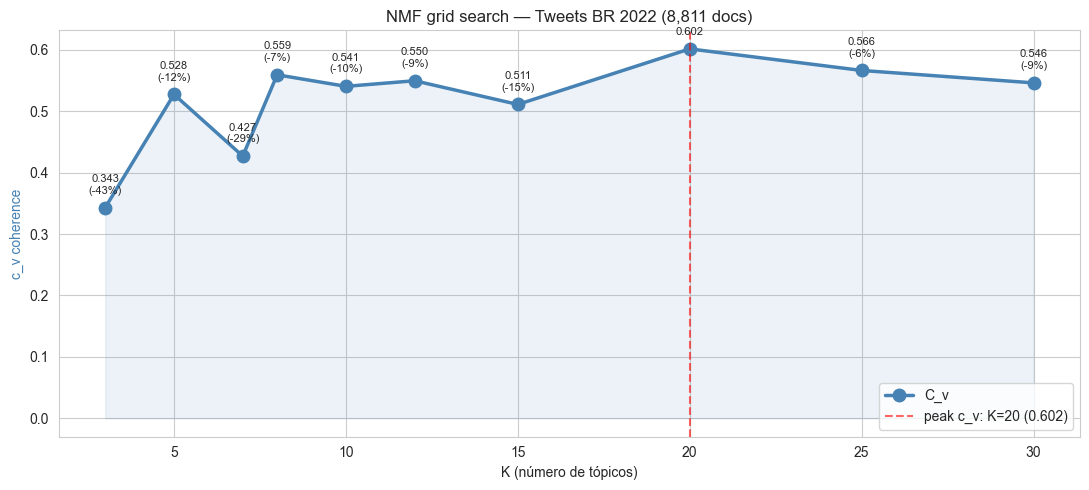


Peak: K=20 (c_v=0.6016)
K=10: c_v=0.5406 (delta vs peak: -10.1%)


In [9]:
# Cell 9 — Visualizacao c_v vs K
fig, ax = plt.subplots(figsize=(11, 5))
ks = sorted(scores)
vs = [scores[k] for k in ks]

ax.plot(ks, vs, marker="o", linewidth=2.5, markersize=9, color="steelblue", label="C_v")
ax.fill_between(ks, vs, alpha=0.1, color="steelblue")

peak_k = max(scores, key=scores.get)
ax.axvline(peak_k, color="red", linestyle="--", alpha=0.6, label=f"peak c_v: K={peak_k} ({scores[peak_k]:.3f})")

# Annotate each K
for k, v in zip(ks, vs):
    delta = (v - scores[peak_k]) / scores[peak_k] * 100
    label = f"{v:.3f}" if k == peak_k else f"{v:.3f}\n({delta:+.0f}%)"
    ax.annotate(label, (k, v), textcoords="offset points", xytext=(0, 10),
                ha="center", fontsize=8)

ax.set_xlabel("K (número de tópicos)"); ax.set_ylabel("c_v coherence", color="steelblue")
ax.set_title(f"NMF grid search — Tweets BR 2022 ({len(docs):,} docs)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(BASE_OUTPUT_DIR / "nmf_grid_k_cv.png", dpi=150, bbox_inches="tight", facecolor="white")
print(f"Salvo: {BASE_OUTPUT_DIR / 'nmf_grid_k_cv.png'}")
plt.show()

print(f"\nPeak: K={peak_k} (c_v={scores[peak_k]:.4f})")
if 10 in scores:
    print(f"K=10: c_v={scores[10]:.4f} (delta vs peak: {(scores[10]-scores[peak_k])/scores[peak_k]*100:+.1f}%)")


## 5. Inspeção qualitativa multi-K

Como `c_v` favorece K menor, precisamos olhar **os tópicos em si** para escolher K com critério metodológico (não só estatístico). Carregamos os tópicos de K=5, 7, 10, 15, 30 pré-computados em `nmf_multi_k_inspect.csv`, se disponível (execução prévia opcional — ver célula abaixo).


In [10]:
# Cell 10 — Multi-K topics side by side (opcional, requer nmf_multi_k_inspect.csv pre-computado)
multi_path = f"{out_dir}/nmf_multi_k_inspect.csv"
if os.path.exists(multi_path):
    multi = pd.read_csv(multi_path)
    for k_val in sorted(multi["k"].unique()):
        sub = multi[multi["k"] == k_val].sort_values("topic_id")
        print(f"=== K={k_val} ===")
        for _, row in sub.iterrows():
            kws = row["keywords"].split(", ")[:8]
            print(f"  T{int(row['topic_id']):2d}: {', '.join(kws)}")
        print()
else:
    print("nmf_multi_k_inspect.csv nao encontrado — pulando inspecao multi-K (opcional).")


nmf_multi_k_inspect.csv nao encontrado — pulando inspecao multi-K (opcional).


In [11]:
# Cell 11 — Distribuição mensal por K (analise visual)
# category = mes de coleta (proxy temporal eleitoral), nao categoria tematica.
# Aqui validamos cobertura temporal (todos os meses representados), nao cobertura de assunto.
month_dist = df['category'].value_counts().sort_index()
print('Distribuicao de docs por mes (proxy temporal, params.yaml: covariates=[category]):')
print(month_dist.to_string())


Distribuicao de docs por mes (proxy temporal, params.yaml: covariates=[category]):
category
2022-08    2621
2022-10    1381
2022-11    2070
2022-12    2739


## 6. Decisão de K e treino final

**Trade-off:** `c_v` favorece K pequeno. Combine com inspeção qualitativa (seção 5) — esperado:
coerência mais baixa que corpus formal (H2), dado o vocabulário esparso de texto curto.
Ajuste `BEST_K` na célula abaixo se necessário.


Faixa de K declarada para tweets_bre2022: [10,25] (5 de 10 pontos admissiveis)
BEST_K pelo protocolo (secao 1.6): 10  (NPMI +0.0863)
  criterio: pareto NPMI x Diversity, desempate menor K
  NOTA: por C_v o argmax na faixa seria K=20 (C_v 0.6016 vs 0.5406 em K=10).
  Divergencia entre eixos e informacao a reportar, nao erro. O NPMI decide.

  K      NPMI       C_v   admissivel
    3  -0.0511  0.3430       - 
    5  +0.0666  0.5275       - 
    7  -0.0186  0.4270       - 
    8  +0.0790  0.5594       - 
   10  +0.0863  0.5406      sim
   12  +0.0774  0.5497      sim
   15  +0.0527  0.5112      sim
   20  +0.1058  0.6016      sim
   25  +0.0893  0.5665      sim
   30  +0.0631  0.5463       - 
Grid kappa (5) × minimum_probability (3) = 15 combos, passes=10...
AVISO: 27 de 8811 documentos com BOW vazio (sem nenhum token no vocabulario pos filter_extremes) -- excluidos do denominador de 'cobertura' (nao ha sinal para nenhum modelo atribuir topico; nao e descarte de minimum_probability).


  done em 414s
 kappa  minimum_probability       cv     NPMI  Diversity  cobertura  n_docs_bow_vazio  k                 corpus_version
   1.0                 0.00 0.546087 0.087213       0.80   1.000000                27 10 tweets_bre2022_20260629_215159
   1.0                 0.01 0.546087 0.087213       0.80   1.000000                27 10 tweets_bre2022_20260629_215159
   1.0                 0.05 0.546087 0.087213       0.80   1.000000                27 10 tweets_bre2022_20260629_215159
   0.5                 0.00 0.536393 0.080313       0.78   1.000000                27 10 tweets_bre2022_20260629_215159
   0.5                 0.01 0.536393 0.080313       0.78   1.000000                27 10 tweets_bre2022_20260629_215159
   0.5                 0.05 0.536393 0.080313       0.78   1.000000                27 10 tweets_bre2022_20260629_215159
   2.0                 0.00 0.517306 0.048485       0.68   0.984745                27 10 tweets_bre2022_20260629_215159
   2.0                 0.

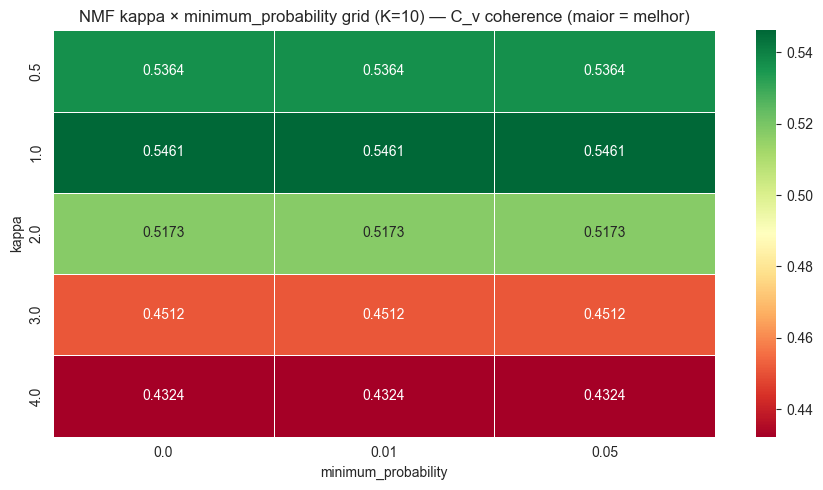


Treinando NMF K=10, kappa=1.0, minimum_probability=0.0, passes=20...


  done em 9s


Erro de reconstrucao (||V-WH||_F / ||V||_F, normalizado): 0.9362

Topics (top-10):
  T 0: ['globolixo', 'hoje', 'dia', 'casa', 'globo', 'falar', 'entrevista', 'puder', 'fique', 'bonner']
  T 1: ['votar', 'nordeste', 'deixem', 'federal', 'polícia', 'rodoviária', 'lulapresidente', 'impedir', 'prf', 'golpe']
  T 2: ['bolsonaro', 'cadeia', 'lula', 'voto', 'acabar', 'bolsonaroreeleito', 'trabalha', 'deixar', 'sirene', 'rombo']
  T 3: ['presidente', 'república', 'diplomação', 'alvorada', 'eleger', 'palácio', 'diplomar', 'silva', 'inácio', 'diploma']
  T 4: ['brasília', 'polícia', 'federal', 'ser', 'bolsonarista', 'terrorista', 'mané', 'prender', 'rodoviária', 'carro']
  T 5: ['lula', 'lulapresidente', 'hoje', 'diplomação', 'dia', 'corte', 'debatenaband', 'bobo', 'brasil', 'posse']
  T 6: ['brasil', 'jair', 'quebrou', 'saqueou', 'rombo', 'bilhões', 'bilhão', 'hora', 'deixar', 'mentiu']
  T 7: ['orçamento', 'secreto', 'pra', 'corte', 'bobo', 'stf', 'bilhão', 'lira', 'rombo', 'mandar']
  T 8: [

In [12]:
# Cell 12 — Grid kappa/minimum_probability (K=BEST_K fixo) + treino final
# PROTOCOLO 2026-08-16 (docs/protocolo-selecao-final-2026-08-16.md, secoes 4.1 e 4.2.2)
# ANTES: BEST_K = argmax(C_v) sobre a grade inteira. Mesma correcao do LDA (secao 4.2.1):
# o eixo de ordenacao do NMF passa a ser o NPMI, dentro da faixa DECLARADA de K (A3,
# fonte unica em _selecao.py) — sem a faixa, todo criterio testado desce para o
# extremo grosso da grade (protocolo secao 3.2, resultado 3).
from _selecao import FAIXA_K, _decidir_curva_k, _porta_cobertura_nmf, _pareto
_k_min, _k_max = FAIXA_K[CORPUS_ID]
_k_admissiveis = [k for k in npmi_scores if _k_min <= k <= _k_max]
if not _k_admissiveis:
    raise ValueError(
        f"nenhum K da grade {sorted(npmi_scores)} cai na faixa declarada "
        f"[{_k_min},{_k_max}] para {CORPUS_ID} — revise a grade ou a faixa, "
        f"mas declare a mudanca antes de olhar os resultados"
    )
_curvas_k = {"NPMI": npmi_scores, "Diversity": div_scores}
BEST_K, _criterio_k = _decidir_curva_k(_curvas_k, _k_min, _k_max)
if BEST_K is None:
    raise ValueError(f"_decidir_curva_k nao achou K admissivel: {_criterio_k}")
_best_k_cv = max(_k_admissiveis, key=lambda k: scores[k])

print(f"Faixa de K declarada para {CORPUS_ID}: [{_k_min},{_k_max}] "
      f"({len(_k_admissiveis)} de {len(npmi_scores)} pontos admissiveis)")
print(f"BEST_K pelo protocolo (secao 1.6): {BEST_K}  (NPMI {npmi_scores[BEST_K]:+.4f})")
print(f"  criterio: {_criterio_k}")
if "FORA do protocolo" in _criterio_k:
    print("  !! sem curva de Diversity no grid — decisao caiu para NPMI puro (fora do protocolo)")
if _best_k_cv != BEST_K:
    print(f"  NOTA: por C_v o argmax na faixa seria K={_best_k_cv} "
          f"(C_v {scores[_best_k_cv]:.4f} vs {scores[BEST_K]:.4f} em K={BEST_K}).")
    print("  Divergencia entre eixos e informacao a reportar, nao erro. O NPMI decide.")

# Curva completa — reportar a CURVA, nao so o argmax.
print("\n  K      NPMI       C_v   admissivel")
for _k in sorted(npmi_scores):
    _adm = "sim" if _k_min <= _k <= _k_max else " - "
    print(f"  {_k:>3d}  {npmi_scores[_k]:+.4f}  {scores[_k]:.4f}      {_adm}")

_khp_cache = f"{BASE_OUTPUT_DIR}/nmf_kappa_minprob_grid.csv"
_kappa_grid = params["evaluation"].get("nmf_kappa_grid", [0.5, 1.0, 2.0])
_min_prob_grid = params["evaluation"].get("nmf_min_prob_grid", [0.0, 0.01, 0.05])

# Cache so e reaproveitado se casar com grid/K/corpus atuais E trouxer as colunas
# que a decisao do protocolo (secao 1.6) exige — evita usar um grid desatualizado
# (ex.: kappa_grid estendido no params.yaml, ou grid anterior a NPMI/Diversity/cobertura,
# que ANTES da correcao de 2026-08-23 era o unico caso: score_by="cv" era o default e
# best_kappa/best_min_prob vinham direto do primeiro estagio sem porta nenhuma).
_khp_cache_valid = False
if os.path.exists(_khp_cache):
    khp_df = pd.read_csv(_khp_cache)
    _cached_kappas = sorted(khp_df["kappa"].unique().tolist()) if "kappa" in khp_df.columns else []
    _cached_min_probs = sorted(khp_df["minimum_probability"].unique().tolist()) if "minimum_probability" in khp_df.columns else []
    _cached_k = int(khp_df["k"].iloc[0]) if "k" in khp_df.columns and len(khp_df) else None
    _cached_corpus_version = khp_df["corpus_version"].iloc[0] if "corpus_version" in khp_df.columns and len(khp_df) else None
    _khp_tem_colunas = all(col in khp_df.columns for col in ("NPMI", "Diversity", "cobertura"))
    _khp_cache_valid = (
        _cached_kappas == sorted(_kappa_grid)
        and _cached_min_probs == sorted(_min_prob_grid)
        and _cached_k == BEST_K
        and _cached_corpus_version == _corpus_dir.name
        and _khp_tem_colunas
    )
    if not _khp_cache_valid:
        print(f"Cache em {_khp_cache} nao bate com grid/K/corpus atuais, ou falta NPMI/Diversity/cobertura "
              f"(protocolo secao 1.6) — recalculando "
              f"(cache: kappas={_cached_kappas}, min_probs={_cached_min_probs}, k={_cached_k}, corpus={_cached_corpus_version} "
              f"| atual: kappas={sorted(_kappa_grid)}, min_probs={sorted(_min_prob_grid)}, k={BEST_K}, corpus=_corpus_dir.name).")

if _khp_cache_valid:
    print(f"Grid kappa/minimum_probability carregado do cache ({_khp_cache}).")
else:
    print(f"Grid kappa ({len(_kappa_grid)}) × minimum_probability ({len(_min_prob_grid)}) = {len(_kappa_grid)*len(_min_prob_grid)} combos, passes=10...")
    t0 = time.time()
    khp_df, _best_kappa_grid, _best_min_prob_grid = grid_search_nmf_hparams(
        corpus_bow, dictionary, tokenized, BEST_K,
        kappa_grid=_kappa_grid, min_prob_grid=_min_prob_grid, seed=seed, passes=10,
        score_by="npmi",
        checkpoint_path=BASE_OUTPUT_DIR / "nmf_hparams_checkpoint.csv",
    )
    khp_df["k"] = BEST_K
    khp_df["corpus_version"] = _corpus_dir.name
    khp_df.to_csv(_khp_cache, index=False)
    print(f"  done em {time.time()-t0:.0f}s")

print(khp_df.to_string(index=False))

# Decisao do protocolo (secao 1.6): porta de cobertura + Pareto NPMI x Diversity
# sobre a grade INTEIRA — best_kappa/best_min_prob de grid_search_nmf_hparams NAO e
# a decisao do protocolo (mesmo com score_by="npmi"): e so um sort escalar de
# conveniencia, e nao aplica a porta de cobertura. Mesma logica que
# _selecao.selecionar_nmf roda sobre o CSV em disco, aplicada aqui inline sobre o
# khp_df ja em memoria (evita reler o CSV que acabou de ser escrito).
_khp_filtrada, _nota_cobertura = _porta_cobertura_nmf(khp_df)
print(f"\n{_nota_cobertura}")
if _khp_filtrada.empty:
    raise ValueError("NENHUM ponto kappa/minimum_probability admissivel apos a porta de cobertura (secao 1.6)")
_khp_fronteira = _pareto(_khp_filtrada, ["NPMI", "Diversity"])
_khp_alvo = _khp_fronteira if not _khp_fronteira.empty else _khp_filtrada
_khp_escolhida = _khp_alvo.sort_values("NPMI", ascending=False).iloc[0]
best_kappa = float(_khp_escolhida["kappa"])
best_min_prob = float(_khp_escolhida["minimum_probability"])
print(f"\n  ★ best_kappa={best_kappa!r}  best_min_prob={best_min_prob!r}  "
      f"(NPMI {_khp_escolhida['NPMI']:+.4f}, cobertura {_khp_escolhida['cobertura']:.4f})")

# Heatmap C_v por kappa × minimum_probability
if len(khp_df) > 1:
    _pivot = khp_df.pivot_table(index="kappa", columns="minimum_probability", values="cv", aggfunc="mean")
    fig, ax = plt.subplots(figsize=(9, max(3, len(_pivot) * 0.8 + 1)))
    sns.heatmap(_pivot, annot=True, fmt=".4f", cmap="RdYlGn", ax=ax, linewidths=0.5)
    ax.set_title(f"NMF kappa × minimum_probability grid (K={BEST_K}) — C_v coherence (maior = melhor)")
    plt.tight_layout(); plt.show()

# Treino final com melhores hiperparâmetros
print(f"\nTreinando NMF K={BEST_K}, kappa={best_kappa!r}, minimum_probability={best_min_prob!r}, passes=20...")
t0 = time.time()
model = train_nmf(corpus_bow, dictionary, k=BEST_K, seed=seed, passes=20, kappa=best_kappa, minimum_probability=best_min_prob)
print(f"  done em {time.time()-t0:.0f}s")

# C4 (protocolo, secao 4.2.2): erro de reconstrucao de Frobenius — analogo da
# perplexidade do LDA, que o gensim.models.Nmf nao expoe.
reconstruction_error = compute_nmf_reconstruction_error(model, corpus_bow)
print(f"Erro de reconstrucao (||V-WH||_F / ||V||_F, normalizado): {reconstruction_error:.4f}")

top_n = params["evaluation"]["top_n_keywords"]
topics_keywords = extract_topics_keywords(model, k=BEST_K, top_n=top_n)

print(f"\nTopics (top-{top_n}):")
for tid in sorted(topics_keywords):
    print(f"  T{tid:2d}: {topics_keywords[tid]}")


Salvo: ..\data\output\tweets_bre2022\nmf\nmf_grid_kappa_minprob_heatmap.png


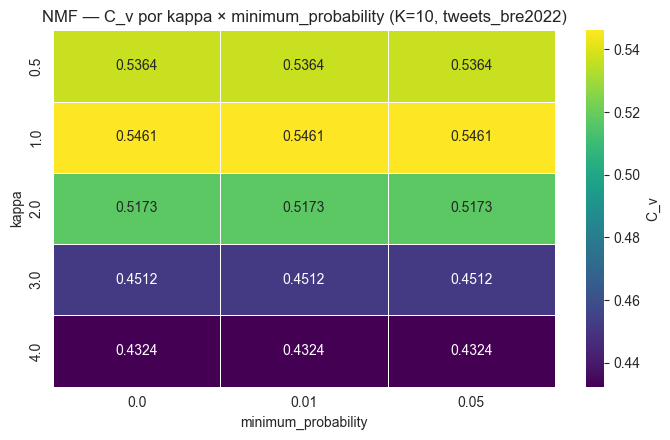

In [13]:
# Heatmap C_v do grid kappa x minimum_probability (le o cache do diretorio-base)
_khp_csv = BASE_OUTPUT_DIR / "nmf_kappa_minprob_grid.csv"
if _khp_csv.exists():
    _g = pd.read_csv(_khp_csv)
    _piv = _g.pivot_table(index="kappa", columns="minimum_probability", values="cv")
    import seaborn as sns
    fig, ax = plt.subplots(figsize=(7, 4.5))
    sns.heatmap(_piv, annot=True, fmt=".4f", cmap="viridis", linewidths=0.5, ax=ax,
                cbar_kws={"label": "C_v"})
    ax.set_title(f"NMF — C_v por kappa × minimum_probability (K={BEST_K}, {CORPUS_ID})")
    plt.tight_layout()
    plt.savefig(BASE_OUTPUT_DIR / "nmf_grid_kappa_minprob_heatmap.png", dpi=150, bbox_inches="tight", facecolor="white")
    print(f"Salvo: {BASE_OUTPUT_DIR / 'nmf_grid_kappa_minprob_heatmap.png'}")
    plt.show()
else:
    print("Sem nmf_kappa_minprob_grid.csv — heatmap pulado")

## 7. Rotulagem via LLM (Ollama)

`_helpers.name_all_topics` envia as keywords pro modelo configurado em `params.yaml` (`llm.model`) via Ollama com prompt few-shot em PT-BR. Em ~9s/tópico em CPU. Fallback: top-3 keywords se Ollama indisponível.


In [14]:
# Cell 15 — Naming
llm_cfg = params.get("llm", {})
print(f"Naming via {llm_cfg.get('model')} ({BEST_K} tópicos × ~9s = ~{BEST_K*9}s)...")

t0 = time.time()
try:
    names = name_all_topics(
        topics_keywords,
        model=llm_cfg["model"],
        base_url=llm_cfg.get("base_url", "http://localhost:11434"),
    )
    print(f"  done em {time.time()-t0:.0f}s")
except Exception as e:
    print(f"  LLM falhou ({e}) — fallback top-3")
    names = {tid: ", ".join(kws[:3]) for tid, kws in topics_keywords.items()}

print()
for tid in sorted(names):
    print(f"  T{tid:2d}: {names[tid]}")
    print(f"        keywords: {topics_keywords[tid][:8]}")


Naming via gemma2:2b-instruct-q4_K_M (10 tópicos × ~9s = ~90s)...


  done em 453s

  T 0: Globo e Lixo
        keywords: ['globolixo', 'hoje', 'dia', 'casa', 'globo', 'falar', 'entrevista', 'puder']
  T 1: Polícia e Rodoviária no Nordeste
        keywords: ['votar', 'nordeste', 'deixem', 'federal', 'polícia', 'rodoviária', 'lulapresidente', 'impedir']
  T 2: Eleições 2022 Brasil
        keywords: ['bolsonaro', 'cadeia', 'lula', 'voto', 'acabar', 'bolsonaroreeleito', 'trabalha', 'deixar']
  T 3: Diplomacia Brasileira
        keywords: ['presidente', 'república', 'diplomação', 'alvorada', 'eleger', 'palácio', 'diplomar', 'silva']
  T 4: Terrorismo em Brasília
        keywords: ['brasília', 'polícia', 'federal', 'ser', 'bolsonarista', 'terrorista', 'mané', 'prender']
  T 5: Lula Diplomação Brasil
        keywords: ['lula', 'lulapresidente', 'hoje', 'diplomação', 'dia', 'corte', 'debatenaband', 'bobo']
  T 6: Saque de Bolsonaro
        keywords: ['brasil', 'jair', 'quebrou', 'saqueou', 'rombo', 'bilhões', 'bilhão', 'hora']
  T 7: Orçamento Secreto e Corte

## 8. Visualização dos tópicos

Wordclouds + bar charts mostram a estrutura semântica de cada tópico. Escala logarítmica destaca palavras menos frequentes mas igualmente representativas.


Salvo: ..\data\output\tweets_bre2022\nmf\tweets_bre2022_20260824_230336\nmf_wordclouds.png


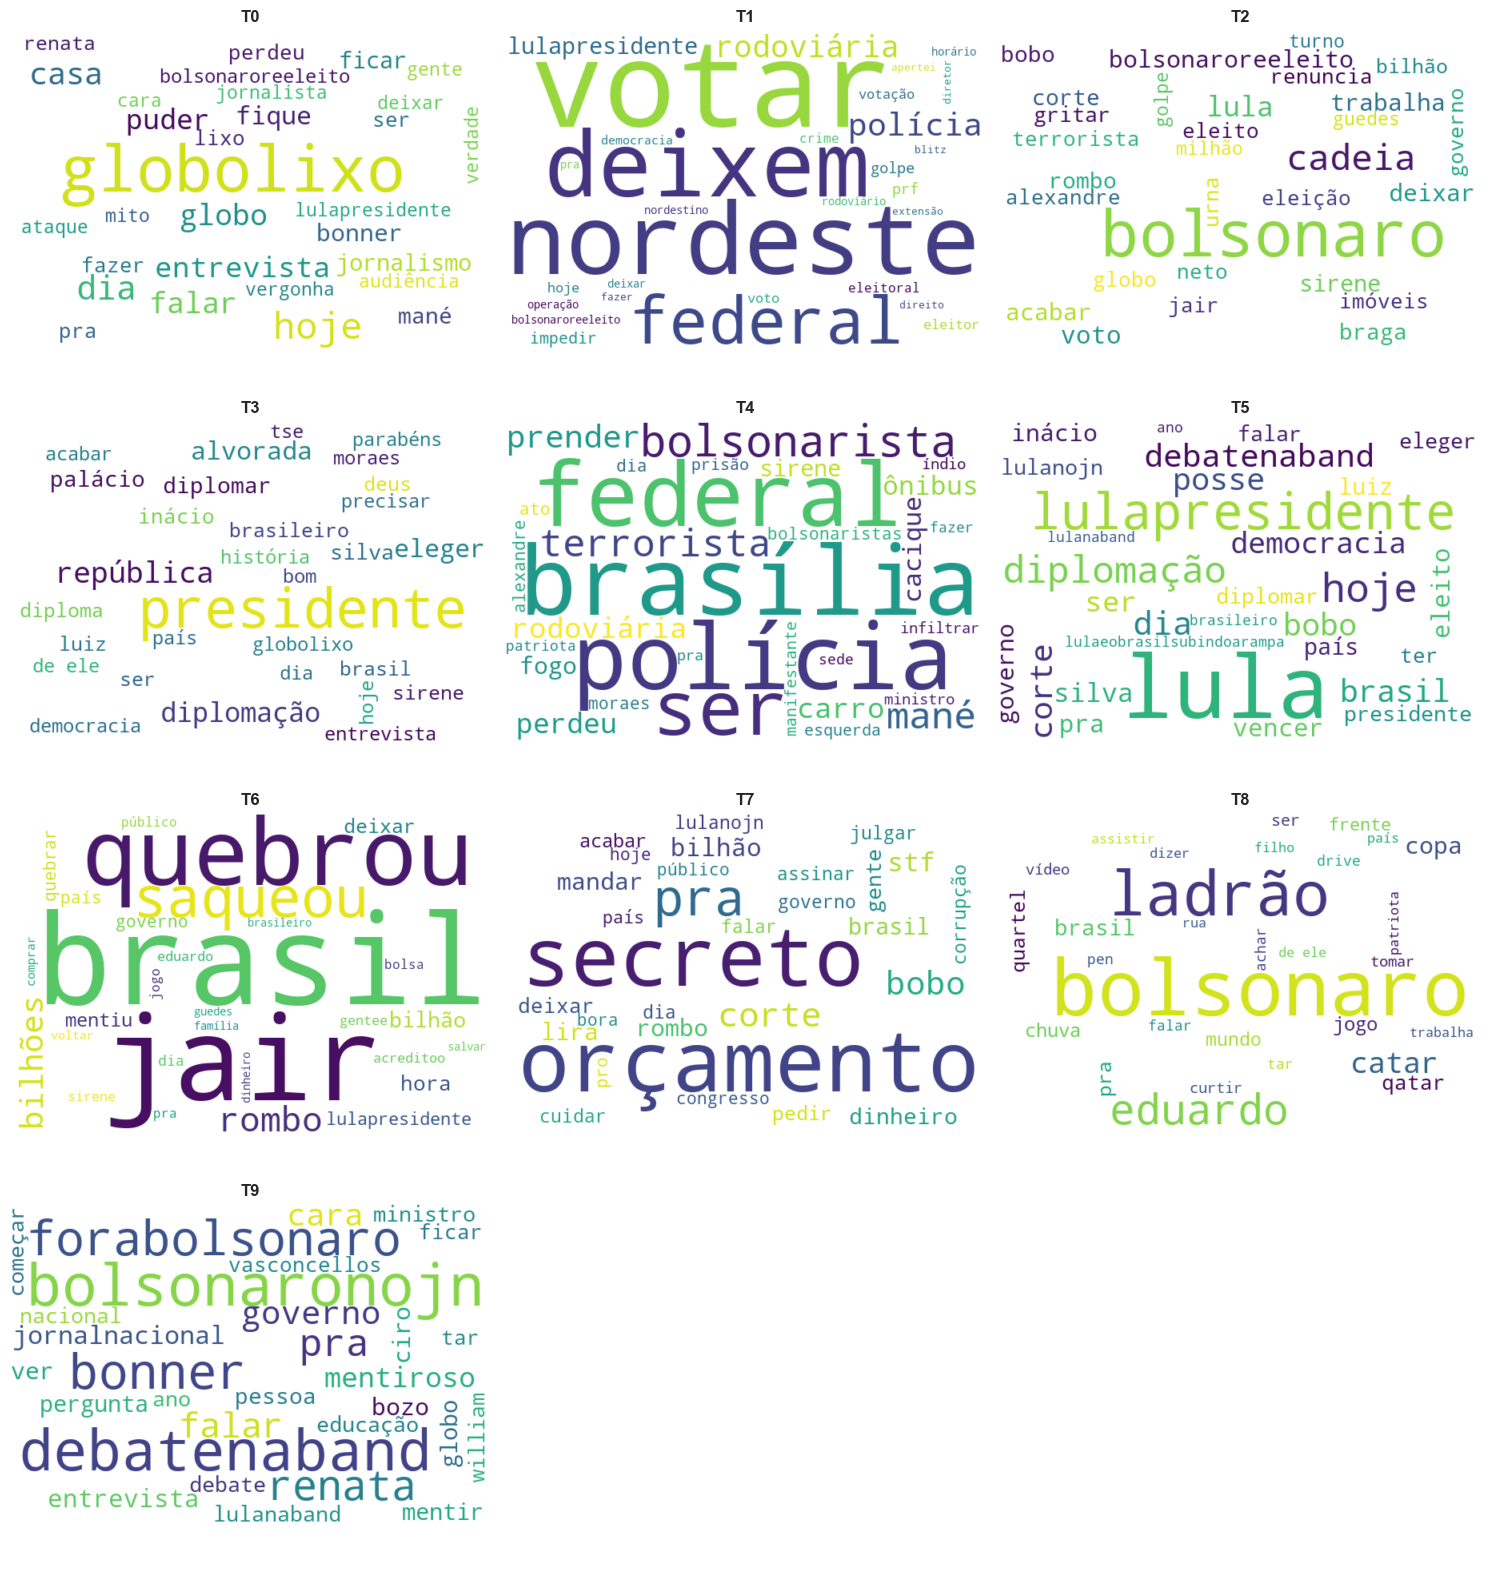

In [15]:
# Cell 13 — Wordclouds (1 por topico)
ncols = 3
nrows = (BEST_K + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten() if BEST_K > 1 else [axes]

_dead_topics = []
for tid in sorted(topics_keywords):
    # gensim show_topic retorna (palavra, prob); usar prob como freq do wordcloud
    word_probs = dict(model.show_topic(tid, topn=30))
    # topico "morto" (sem massa de probabilidade, comum com K alto em texto curto):
    # show_topic pode retornar NaN quando a linha normaliza 0/0
    valid_probs = {w: p for w, p in word_probs.items() if np.isfinite(p) and p > 0}
    axes[tid].set_title(f"T{tid}", fontsize=12, fontweight="bold")
    axes[tid].axis("off")
    if not valid_probs:
        _dead_topics.append(tid)
        axes[tid].text(0.5, 0.5, "topico degenerado\n(sem massa de probabilidade)",
                       ha="center", va="center", fontsize=9, color="gray", wrap=True)
        continue
    wc = WordCloud(width=600, height=400, background_color="white",
                   colormap="viridis", max_words=30, prefer_horizontal=0.9).generate_from_frequencies(valid_probs)
    axes[tid].imshow(wc, interpolation="bilinear")

# Esconde axes nao usados
for i in range(BEST_K, len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "nmf_wordclouds.png", dpi=150, bbox_inches="tight", facecolor="white")
print(f"Salvo: {OUTPUT_DIR / 'nmf_wordclouds.png'}")
plt.show()

if _dead_topics:
    print(f"AVISO: {len(_dead_topics)} topico(s) degenerado(s) (sem massa de probabilidade): {_dead_topics}")
    print("  Indica K provavelmente alto demais para o vocabulario esparso deste corpus — considere revisar BEST_K.")



Salvo: ..\data\output\tweets_bre2022\nmf\tweets_bre2022_20260824_230336\nmf_keywords_barchart.png


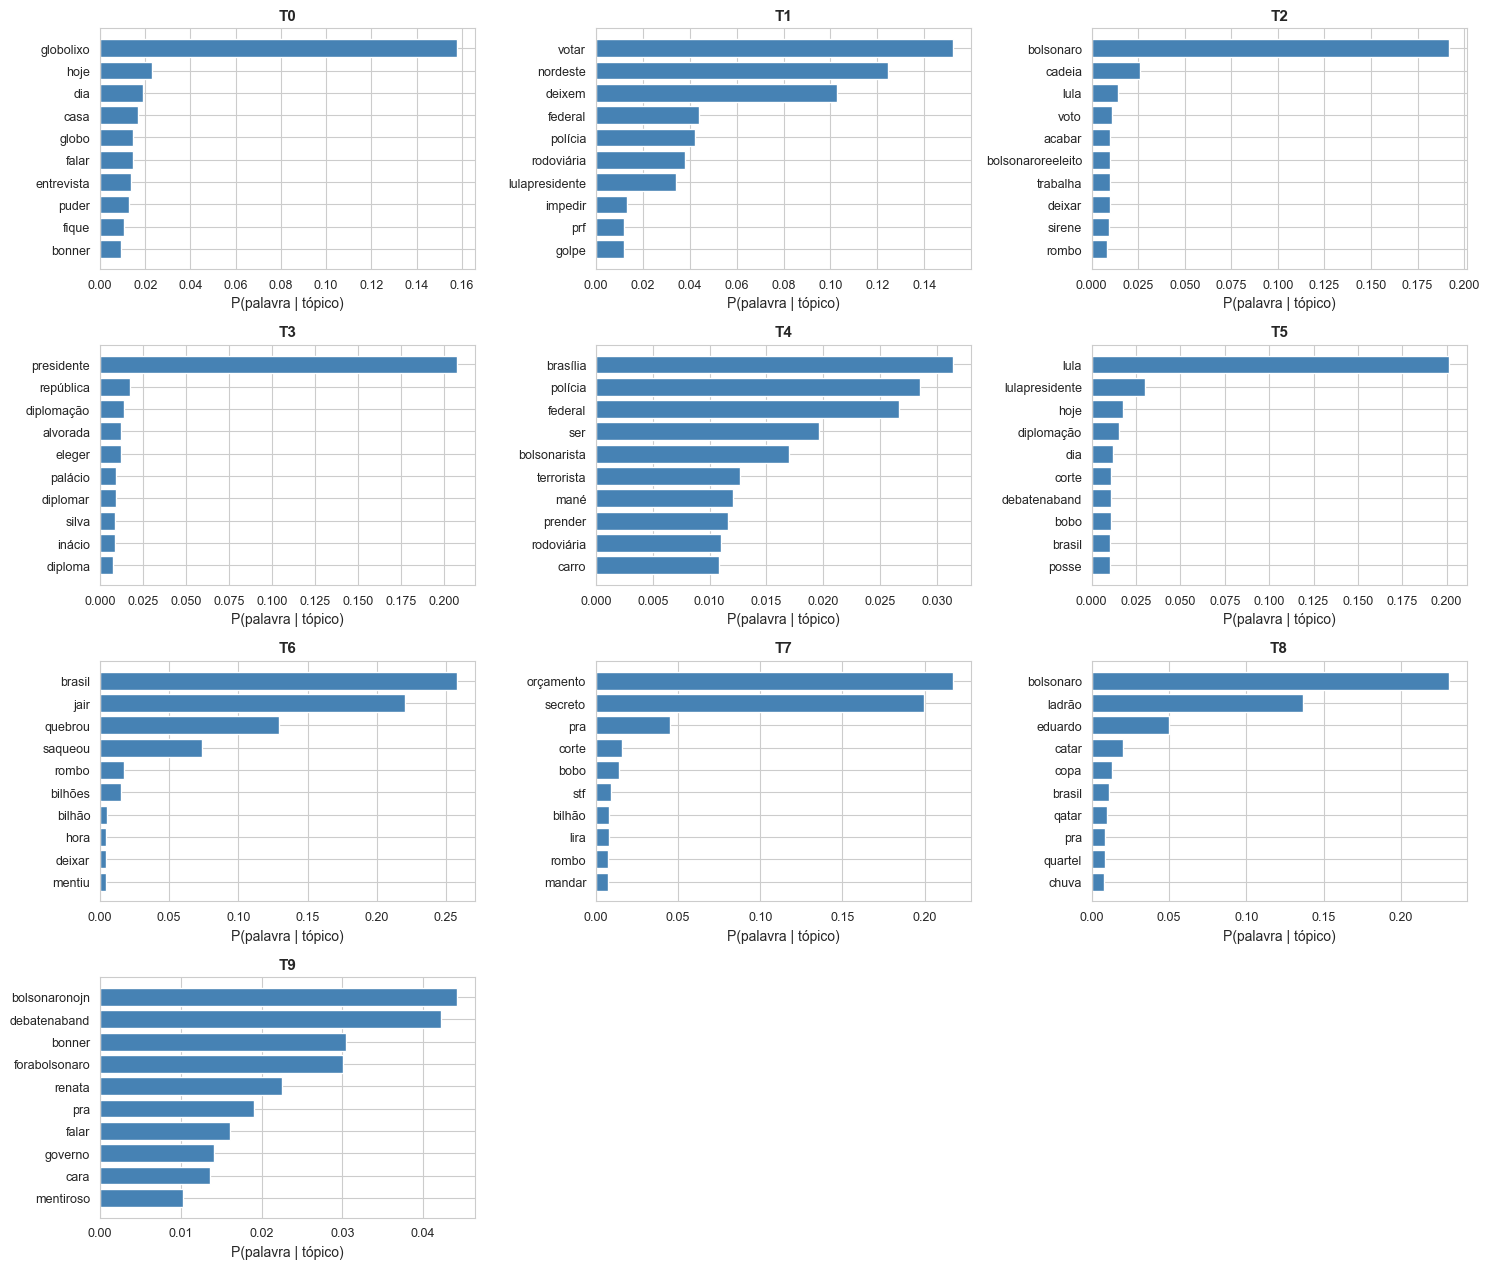

In [16]:
# Cell 14 — Bar chart top-10 keywords per topic
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.2 * nrows))
axes = axes.flatten() if BEST_K > 1 else [axes]

for tid in sorted(topics_keywords):
    word_probs = model.show_topic(tid, topn=10)
    words, probs = zip(*word_probs)
    axes[tid].barh(list(words)[::-1], list(probs)[::-1], color="steelblue")
    axes[tid].set_title(f"T{tid}", fontsize=11, fontweight="bold")
    axes[tid].set_xlabel("P(palavra | tópico)")
    axes[tid].tick_params(labelsize=9)

for i in range(BEST_K, len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "nmf_keywords_barchart.png", dpi=150, bbox_inches="tight", facecolor="white")
print(f"Salvo: {OUTPUT_DIR / 'nmf_keywords_barchart.png'}")
plt.show()


## Similaridade e redundância entre tópicos

O NMF não penaliza sobreposição de vocabulário entre tópicos (ao contrário do
LDA, que tem prior Dirichlet). Dois diagnósticos visuais:

- **Similaridade cosseno** entre as linhas de `φ` (tópico×vocabulário) — pares
  com similaridade alta são candidatos a merge ou a K menor.
- **Termite plot** — peso de cada termo (união dos top termos) em cada tópico,
  num único quadro.

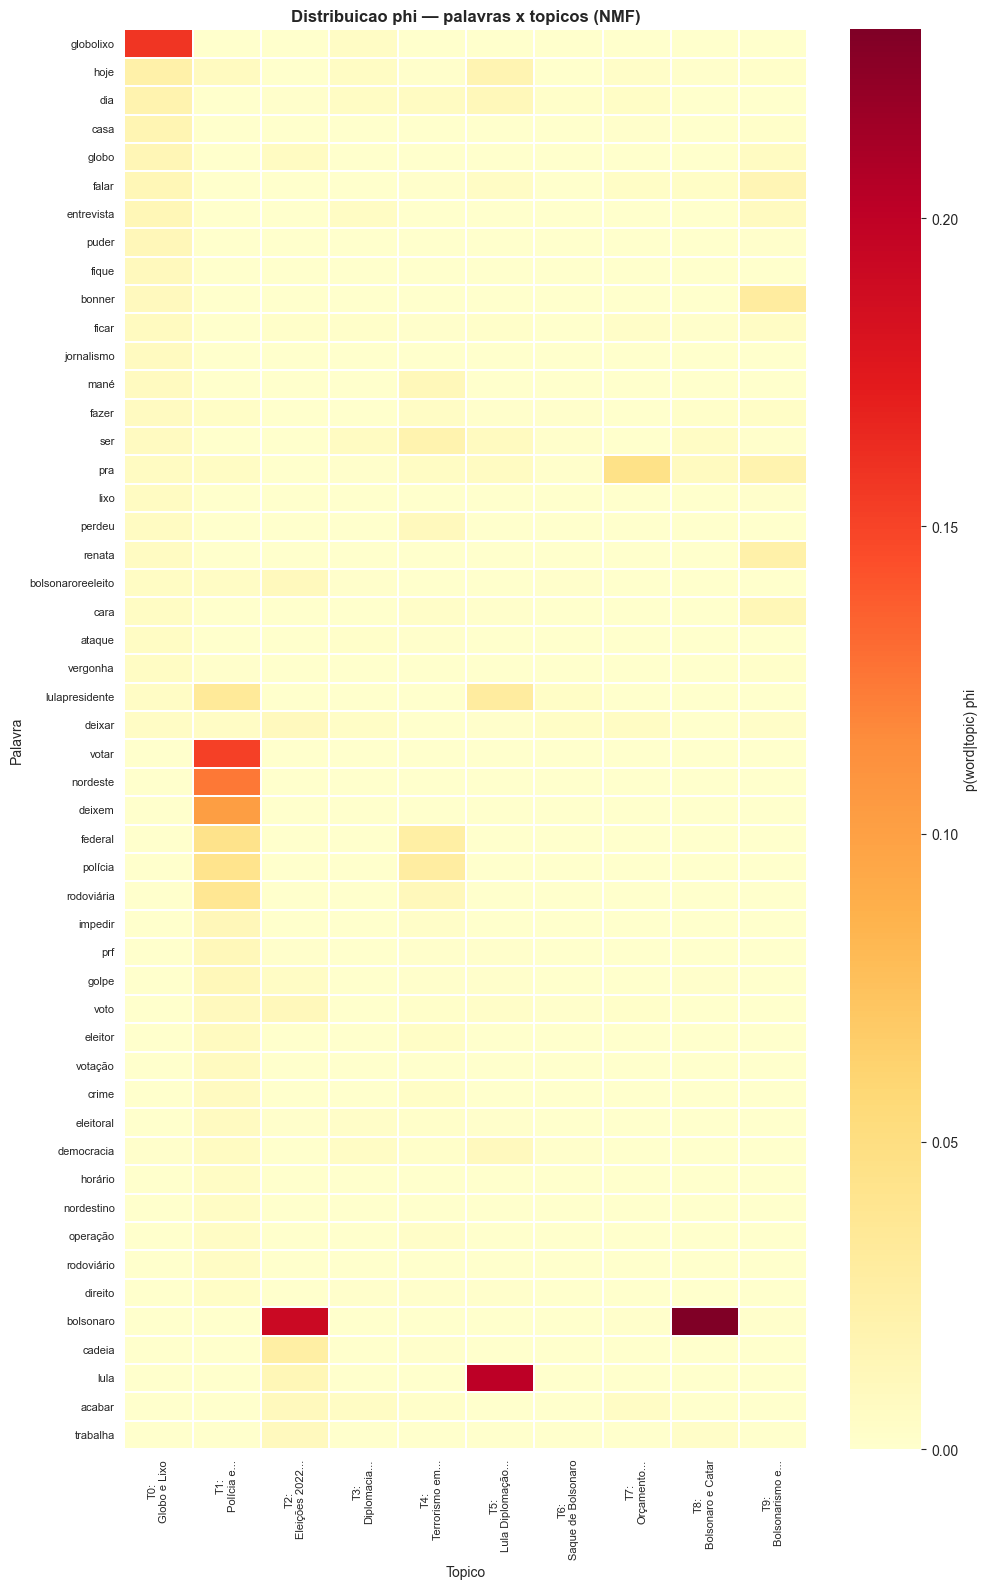

Salvo: ..\data\output\tweets_bre2022\nmf\tweets_bre2022_20260824_230336\nmf_heatmap_phi.png


In [17]:
# Heatmap phi: top palavras x topicos (mesmo formato do LDA — 02_lda_folha.ipynb)
import seaborn as sns
_top_n_phi = 25
_all_words = []
for tid in range(BEST_K):
    for w, _ in model.show_topic(tid, topn=_top_n_phi):
        if w not in _all_words:
            _all_words.append(w)
_all_words = _all_words[:min(50, len(_all_words))]

_phi_hm = np.zeros((len(_all_words), BEST_K))
for tid in range(BEST_K):
    _td = dict(model.show_topic(tid, topn=200))
    for wi, w in enumerate(_all_words):
        _phi_hm[wi, tid] = _td.get(w, 0.0)

import textwrap as _tw_phi
_col_labels = [f"T{t}:\n{_tw_phi.shorten(str(names.get(t, '')), 18, placeholder='...')}" for t in range(BEST_K)]
_phi_hm_df = pd.DataFrame(_phi_hm, index=_all_words, columns=_col_labels)

fig, ax = plt.subplots(figsize=(max(10, BEST_K * 0.8), max(8, len(_all_words) * 0.32)))
sns.heatmap(_phi_hm_df, cmap="YlOrRd", ax=ax, linewidths=0.15,
            cbar_kws={"label": "p(word|topic) phi"})
ax.set_title("Distribuicao phi — palavras x topicos (NMF)", fontsize=12, fontweight="bold")
ax.set_xlabel("Topico"); ax.set_ylabel("Palavra")
plt.xticks(fontsize=8); plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "nmf_heatmap_phi.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Salvo: {OUTPUT_DIR / 'nmf_heatmap_phi.png'}")

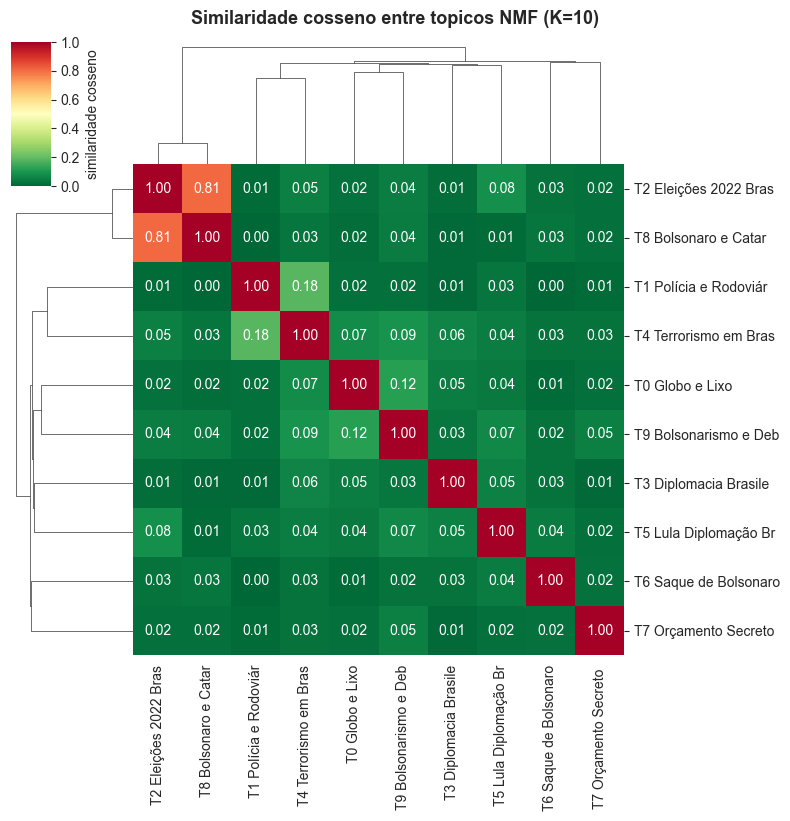

Top 5 pares de topicos mais similares (candidatos a redundancia):
  T2 <-> T8: cos=0.808  [Eleições 2022 Brasil | Bolsonaro e Catar]
  T1 <-> T4: cos=0.182  [Polícia e Rodoviária no Nordes | Terrorismo em Brasília]
  T0 <-> T9: cos=0.117  [Globo e Lixo | Bolsonarismo e Debate]
  T4 <-> T9: cos=0.091  [Terrorismo em Brasília | Bolsonarismo e Debate]
  T2 <-> T5: cos=0.083  [Eleições 2022 Brasil | Lula Diplomação Brasil]


In [18]:
# Similaridade cosseno entre topicos (candidatos a redundancia/merge)
from scipy.spatial.distance import squareform, pdist

_phi_sim = model.get_topics()  # (K, vocab_size)
_sim = 1 - squareform(pdist(_phi_sim, metric="cosine"))
_sim_labels = [f"T{tid} {names[tid][:18]}" for tid in range(BEST_K)]
_sim_df = pd.DataFrame(_sim, index=_sim_labels, columns=_sim_labels)

g = sns.clustermap(_sim_df, cmap="RdYlGn_r", vmin=0, vmax=1,
                    figsize=(max(8, BEST_K * 0.55), max(8, BEST_K * 0.55)),
                    annot=BEST_K <= 15, fmt=".2f", cbar_kws={"label": "similaridade cosseno"})
g.fig.suptitle(f"Similaridade cosseno entre topicos NMF (K={BEST_K})", y=1.02, fontsize=13, fontweight="bold")
g.savefig(OUTPUT_DIR / "nmf_topic_similarity.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

_iu = np.triu_indices_from(_sim, k=1)
_pairs = sorted(zip(_sim[_iu], zip(_iu[0], _iu[1])), reverse=True)[:5]
print("Top 5 pares de topicos mais similares (candidatos a redundancia):")
for score, (i, j) in _pairs:
    print(f"  T{i} <-> T{j}: cos={score:.3f}  [{names[i][:30]} | {names[j][:30]}]")

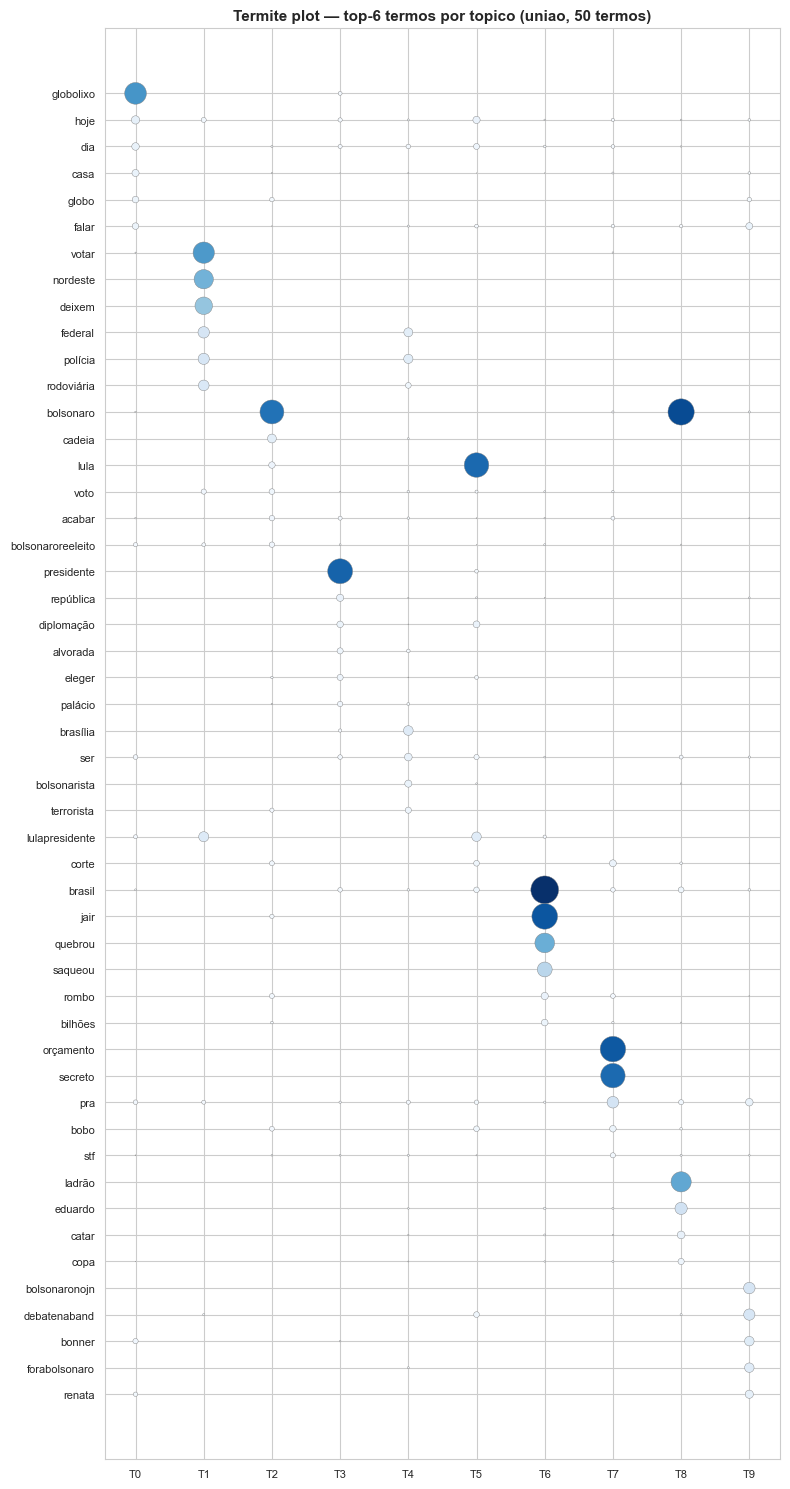

In [19]:
# Termite plot: peso topico x termo (uniao dos top termos por topico)
_TERMITE_TOPN = 6
_term_union, _seen_terms = [], set()
for tid in sorted(topics_keywords):
    for w in topics_keywords[tid][:_TERMITE_TOPN]:
        if w not in _seen_terms:
            _seen_terms.add(w)
            _term_union.append(w)

_phi_term = model.get_topics()  # (K, vocab_size)
_vocab_idx_term = {dictionary[i]: i for i in range(len(dictionary))}
_termite = pd.DataFrame(
    {f"T{tid}": [_phi_term[tid, _vocab_idx_term[w]] if w in _vocab_idx_term else 0.0 for w in _term_union]
     for tid in range(BEST_K)},
    index=_term_union,
)

fig, ax = plt.subplots(figsize=(max(8, BEST_K * 0.6), max(6, len(_term_union) * 0.3)))
_xx, _yy = np.meshgrid(range(BEST_K), range(len(_term_union)))
_sizes = _termite.values / _termite.values.max() * 400
ax.scatter(_xx.flatten(), _yy.flatten(), s=_sizes.flatten(), c=_sizes.flatten(),
           cmap="Blues", edgecolors="gray", linewidths=0.3)
ax.set_xticks(range(BEST_K)); ax.set_xticklabels([f"T{t}" for t in range(BEST_K)], fontsize=8)
ax.set_yticks(range(len(_term_union))); ax.set_yticklabels(_term_union, fontsize=8)
ax.set_title(f"Termite plot — top-{_TERMITE_TOPN} termos por topico (uniao, {len(_term_union)} termos)",
             fontsize=11, fontweight="bold")
ax.invert_yaxis()
plt.tight_layout(); plt.show()

## 9. Métricas quantitativas

- **c_v** recomputada (validação cruzada do grid)
- **Exclusivity**: 1 - prop. de keywords compartilhadas entre tópicos
- **Topic Diversity**: razão de palavras únicas no consolidado dos top-K
- **Diversity entropy** das distribuições θ doc-tópico (quão espalhadas)


Calculando métricas...


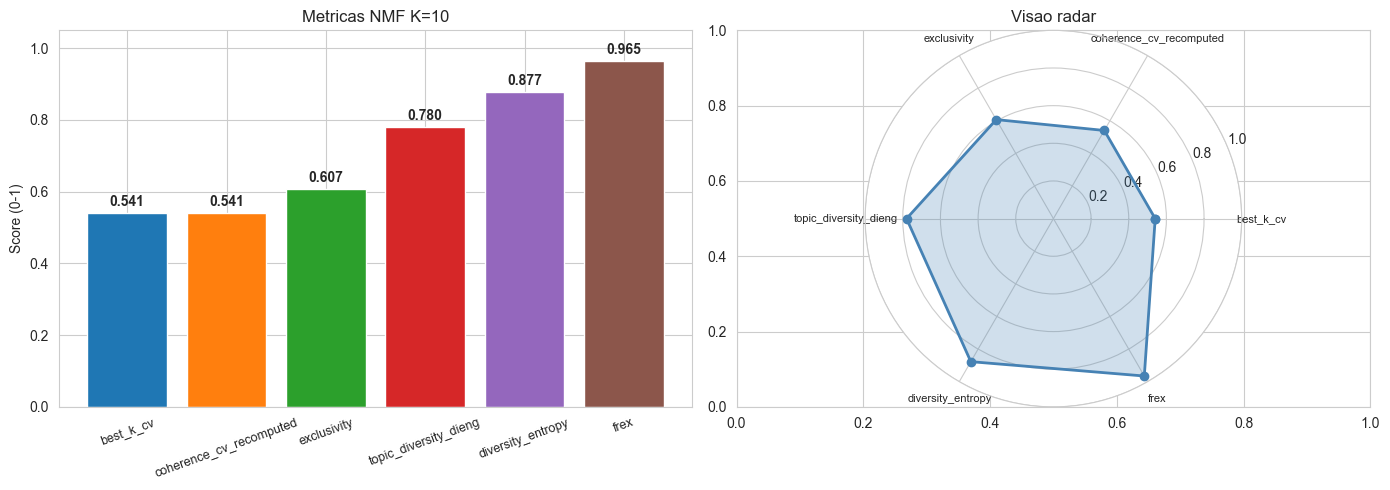

{
  "model": "nmf",
  "topic_type": "probabilistic",
  "granularity": "unit",
  "corpus": "tweets_bre2022",
  "n_topics": 10,
  "best_k_cv": 0.540610291971277,
  "exclusivity": 0.6072652906867546,
  "diversity_entropy": 0.87729045381655,
  "topic_diversity_dieng": 0.78,
  "frex": 0.9652847156182212,
  "coherence_cv_recomputed": 0.540610291971277
}


In [20]:
# Cell 16 — Calcula metricas
print("Calculando métricas...")
dominant, full = compute_doc_distributions(model, corpus_bow, k=BEST_K)

# FREX + exclusividade c-TF-IDF (MESMA metrica do LDA/BERTopic/folha) — usa a
# matriz de topicos completa do gensim, nao a versao binaria (compute_exclusivity)
_phi = model.get_topics()  # shape (BEST_K, vocab_size)
_vocab_idx = {dictionary[i]: i for i in range(len(dictionary))}
_topic_idx = {tid: tid for tid in range(BEST_K)}
_top_n_metrics = params["evaluation"].get("top_n_keywords_metrics", 20)
frex_mean, frex_per_topic = compute_frex_score(
    topics_keywords, _phi, _vocab_idx, _topic_idx, top_n=_top_n_metrics,
)
_topic_word_scores_nmf = {
    tid: {dictionary[i]: float(_phi[tid, i]) for i in range(_phi.shape[1]) if _phi[tid, i] > 0}
    for tid in range(BEST_K)
}
_excl_mean, _excl_per_topic = compute_exclusivity_ctfidf(
    topics_keywords, _topic_word_scores_nmf, top_n=_top_n_metrics,
)

metrics = {
    "model": "nmf",
    "topic_type": "probabilistic",
    "granularity": "unit",
    "corpus": CORPUS_ID,
    "n_topics": BEST_K,
    "best_k_cv": float(scores.get(BEST_K, 0.0)),
    "exclusivity": float(_excl_mean),
    "diversity_entropy": float(compute_diversity(full)),
    "topic_diversity_dieng": float(compute_topic_diversity(topics_keywords)),
    "frex": float(frex_mean),
}
metrics["coherence_cv_recomputed"] = float(compute_coherence_cv(topics_keywords, tokenized, dictionary))

# Visualiza num radar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
metric_keys = ["best_k_cv", "coherence_cv_recomputed", "exclusivity",
               "topic_diversity_dieng", "diversity_entropy", "frex"]
metric_vals = [metrics[k] for k in metric_keys]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]
axes[0].bar(metric_keys, metric_vals, color=colors)
axes[0].set_ylim(0, 1.05); axes[0].set_ylabel("Score (0-1)")
axes[0].set_title(f"Metricas NMF K={BEST_K}")
axes[0].tick_params(axis="x", rotation=20, labelsize=9)
for i, (k, v) in enumerate(zip(metric_keys, metric_vals)):
    axes[0].text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=10, fontweight="bold")

# Radar
angles = np.linspace(0, 2*np.pi, len(metric_keys), endpoint=False).tolist()
vals = metric_vals + [metric_vals[0]]
angles_p = angles + [angles[0]]
axes[1] = plt.subplot(122, projection="polar")
axes[1].plot(angles_p, vals, "o-", linewidth=2, color="steelblue")
axes[1].fill(angles_p, vals, alpha=0.25, color="steelblue")
axes[1].set_xticks(angles); axes[1].set_xticklabels(metric_keys, fontsize=8)
axes[1].set_ylim(0, 1)
axes[1].set_title("Visao radar")

plt.tight_layout(); plt.show()
print(json.dumps(metrics, indent=2))

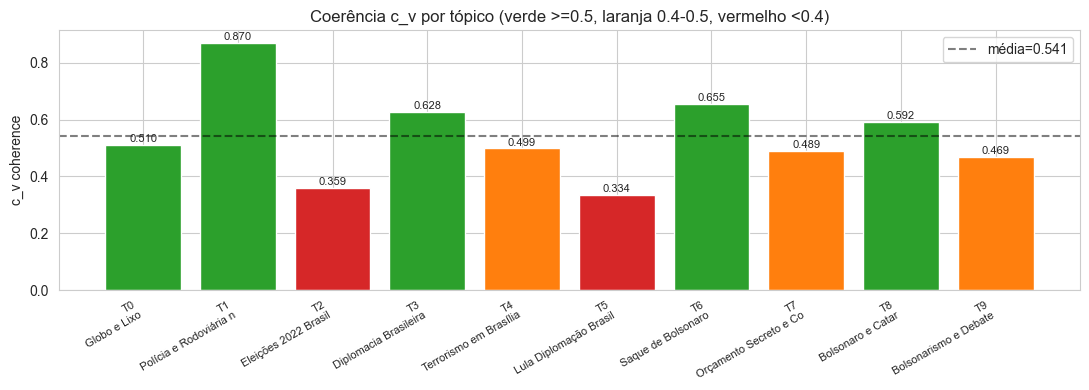

In [21]:
# Cell 17 — c_v por topico (nao so media)
from gensim.models import CoherenceModel
cm = CoherenceModel(
    topics=[topics_keywords[tid] for tid in sorted(topics_keywords)],
    texts=tokenized, dictionary=dictionary, coherence="c_v",
)
per_topic_cv = cm.get_coherence_per_topic()

fig, ax = plt.subplots(figsize=(11, 4))
tids = sorted(topics_keywords)
labels = [f"T{tid}\n{names[tid][:22]}" for tid in tids]
bars = ax.bar(tids, per_topic_cv, color=["#2ca02c" if c >= 0.5 else "#ff7f0e" if c >= 0.4 else "#d62728" for c in per_topic_cv])
ax.axhline(np.mean(per_topic_cv), color="black", linestyle="--", alpha=0.5, label=f"média={np.mean(per_topic_cv):.3f}")
ax.set_xticks(tids); ax.set_xticklabels(labels, fontsize=8, rotation=30, ha="right")
ax.set_ylabel("c_v coherence"); ax.set_title("Coerência c_v por tópico (verde >=0.5, laranja 0.4-0.5, vermelho <0.4)")
ax.legend()
for bar, c in zip(bars, per_topic_cv):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{c:.3f}",
            ha="center", fontsize=8)
plt.tight_layout(); plt.show()


## 10. Distribuição de documentos por tópico

Mostra balanceamento dos clusters. Distribuição muito desigual pode indicar:
- 1 tópico "lixo" capturando outliers
- K muito alto fragmentando o sinal
- Picos de discurso eleitoral concentrados em poucos temas dominantes (esperado em corpus político)


Salvo: ..\data\output\tweets_bre2022\nmf\tweets_bre2022_20260824_230336\nmf_docs_por_topico.png


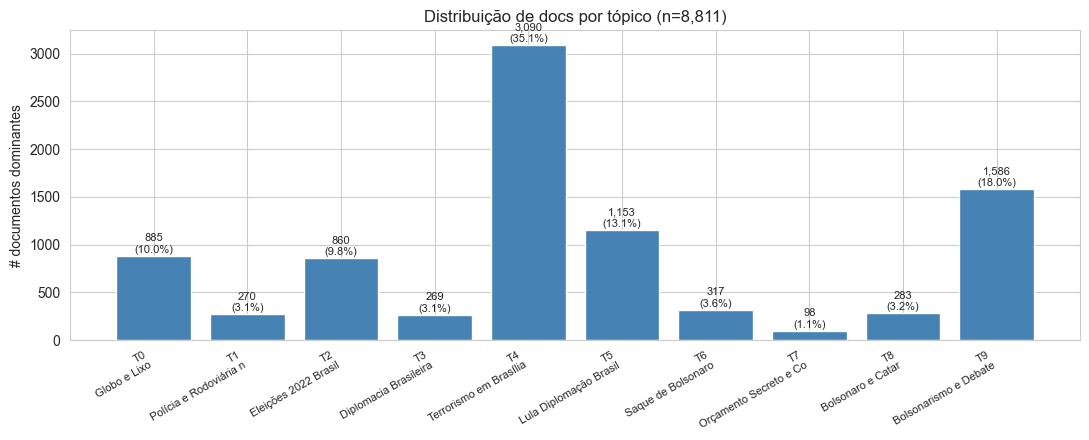


Docs por tópico — descritivas: {'count': 10.0, 'mean': 881.1, 'std': 912.1282134534475, 'min': 98.0, '25%': 273.25, '50%': 588.5, '75%': 1086.0, 'max': 3090.0}


In [22]:
# Cell 18 — Bar chart docs por topico
topic_doc_counts = pd.Series(dominant).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(11, 4.5))
labels = [f"T{tid}\n{names[tid][:22]}" for tid in topic_doc_counts.index]
bars = ax.bar(topic_doc_counts.index, topic_doc_counts.values, color="steelblue")
ax.set_xticks(topic_doc_counts.index); ax.set_xticklabels(labels, fontsize=8, rotation=30, ha="right")
ax.set_ylabel("# documentos dominantes")
ax.set_title(f"Distribuição de docs por tópico (n={len(docs):,})")
for bar, c in zip(bars, topic_doc_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, c + max(topic_doc_counts)*0.01,
            f"{c:,}\n({c/len(docs)*100:.1f}%)", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "nmf_docs_por_topico.png", dpi=150, bbox_inches="tight", facecolor="white")
print(f"Salvo: {OUTPUT_DIR / 'nmf_docs_por_topico.png'}")
plt.show()

print(f"\nDocs por tópico — descritivas: {topic_doc_counts.describe().to_dict()}")


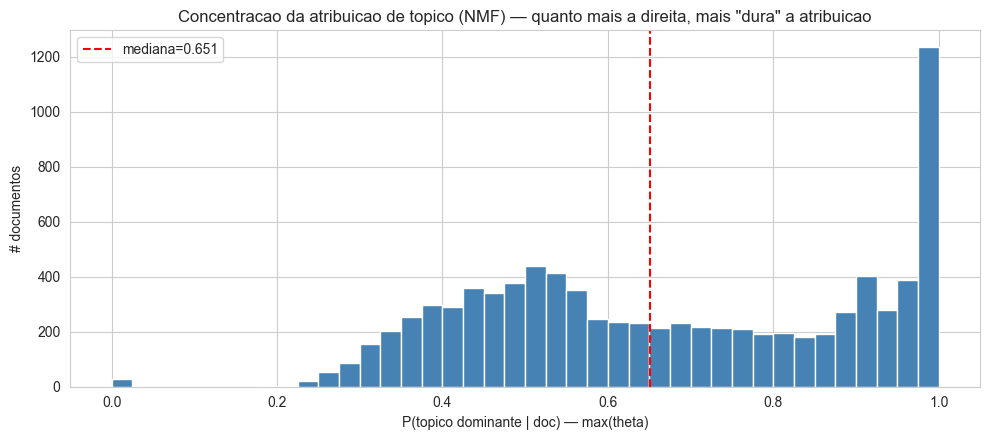

max(theta) — media=0.674, mediana=0.651, % docs com max(theta) < 0.3 (atribuicao difusa): 2.2%


In [23]:
# Histograma da probabilidade do topico dominante (dureza da atribuicao NMF)
_theta_full = np.array(full)
_max_prob = _theta_full.max(axis=1)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(_max_prob, bins=40, color="steelblue", edgecolor="white")
ax.axvline(np.median(_max_prob), color="red", linestyle="--",
           label=f"mediana={np.median(_max_prob):.3f}")
ax.set_xlabel("P(topico dominante | doc) — max(theta)"); ax.set_ylabel("# documentos")
ax.set_title("Concentracao da atribuicao de topico (NMF) — quanto mais a direita, mais \"dura\" a atribuicao")
ax.legend()
plt.tight_layout(); plt.show()

print(f"max(theta) — media={_max_prob.mean():.3f}, mediana={np.median(_max_prob):.3f}, "
      f"% docs com max(theta) < 0.3 (atribuicao difusa): {(_max_prob < 0.3).mean()*100:.1f}%")

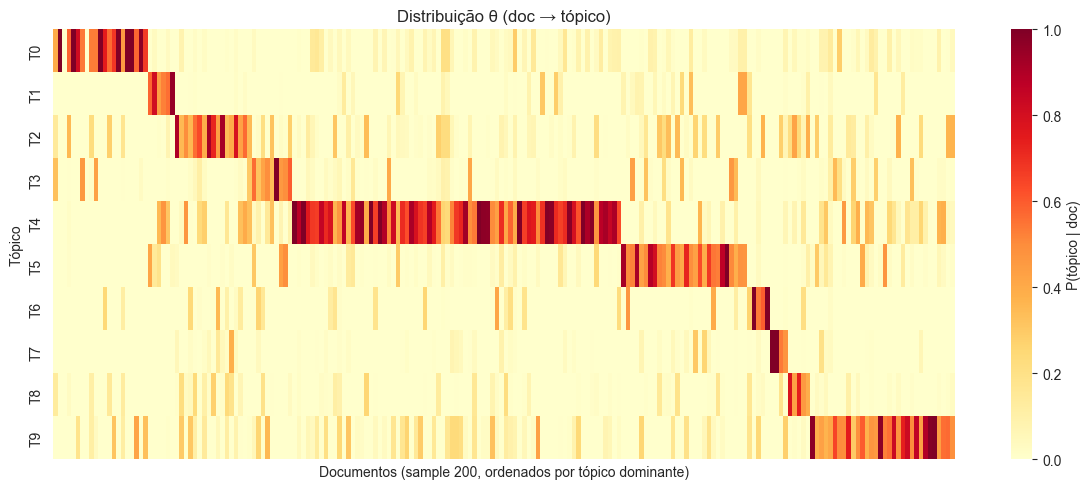

In [24]:
# Cell 19 — Heatmap theta (doc x topico) — sample
sample_n = min(200, len(full))
sample_idx = np.random.RandomState(42).choice(len(full), sample_n, replace=False)
theta_sample = np.array([full[i] for i in sample_idx])

# Sort sample by dominant topic for readability
sample_dom = theta_sample.argmax(axis=1)
order = np.argsort(sample_dom)
theta_sorted = theta_sample[order]

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(theta_sorted.T, cmap="YlOrRd", cbar_kws={"label": "P(tópico | doc)"},
            xticklabels=False, yticklabels=[f"T{i}" for i in range(BEST_K)], ax=ax)
ax.set_xlabel(f"Documentos (sample {sample_n}, ordenados por tópico dominante)")
ax.set_ylabel("Tópico"); ax.set_title("Distribuição θ (doc → tópico)")
plt.tight_layout(); plt.show()


## t-SNE do espaço de tópicos (θ)

Reduz a matriz θ (N×K) a 2D via t-SNE. Gera PNG colorido por tópico dominante e versão HTML interativa com hover do texto.


Calculando t-SNE sobre matriz theta...


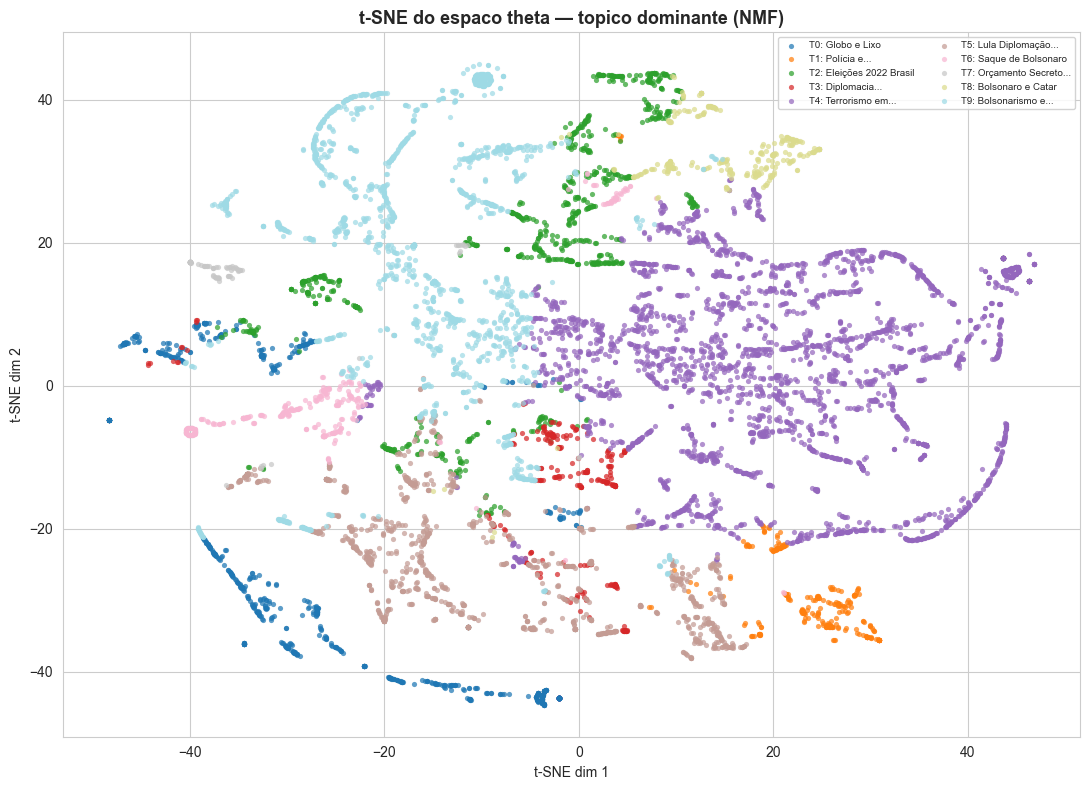

Salvo: ..\data\output\tweets_bre2022\nmf\tweets_bre2022_20260824_230336\nmf_tsne_theta_topico.png


Salvo: ..\data\output\tweets_bre2022\nmf\tweets_bre2022_20260824_230336\nmf_tsne_theta_interactive.html


In [25]:
import plotly.express as px
from sklearn.manifold import TSNE

_theta_mat = np.array(full)  # (n_docs, K)
_texts_nmf = [t[:100] + "..." if len(t) > 100 else t for t in docs]

print("Calculando t-SNE sobre matriz theta...")
_tsne = TSNE(n_components=2, perplexity=30, random_state=seed, max_iter=500)
_theta_2d = _tsne.fit_transform(_theta_mat)

_cmap_nmf = plt.get_cmap("tab20", max(BEST_K, 1))

# PNG por topico dominante
fig, ax = plt.subplots(figsize=(11, 8))
for tid in range(BEST_K):
    _mm = np.array(dominant) == tid
    if _mm.any():
        import textwrap as _tw_u
        _nm = _tw_u.shorten(str(names.get(tid, "")), 20, placeholder="...")
        ax.scatter(_theta_2d[_mm, 0], _theta_2d[_mm, 1],
                   c=[_cmap_nmf(tid)], s=14, alpha=0.72, linewidths=0,
                   label=f"T{tid}: {_nm}")
ax.set_title("t-SNE do espaco theta — topico dominante (NMF)", fontsize=13, fontweight="bold")
ax.set_xlabel("t-SNE dim 1"); ax.set_ylabel("t-SNE dim 2")
ax.legend(loc="best", fontsize=7, framealpha=0.85, ncol=2)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "nmf_tsne_theta_topico.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Salvo: {OUTPUT_DIR / 'nmf_tsne_theta_topico.png'}")

# HTML interativo por topico dominante
import textwrap as _tw_u2
_tsne_df_nmf = pd.DataFrame({
    "x": _theta_2d[:, 0], "y": _theta_2d[:, 1],
    "Texto": _texts_nmf,
    "Topico": [f"T{t}: {_tw_u2.shorten(str(names.get(t,"")), 25, placeholder="...")}" for t in dominant],
})
fig_u = px.scatter(
    _tsne_df_nmf, x="x", y="y", color="Topico",
    hover_data={"x": False, "y": False, "Texto": True},
    title="t-SNE espaco theta — topico dominante (interativo, NMF)",
    labels={"x": "t-SNE dim 1", "y": "t-SNE dim 2"}, opacity=0.72,
)
fig_u.update_traces(marker_size=5)
_out_u = OUTPUT_DIR / "nmf_tsne_theta_interactive.html"
fig_u.write_html(_out_u)
fig_u.show()
print(f"Salvo: {_out_u}")


## Cross-tab tópico × mês

Para os tweets, a "categoria" é o mês eleitoral (YYYY-MM) — mesmo eixo usado
pela fórmula de prevalência do STM. Mostra deslocamento da agenda ao longo da
campanha (1º turno → 2º turno → pós-eleição).


Salvo: ..\data\output\tweets_bre2022\nmf\tweets_bre2022_20260824_230336\nmf_topic_category.png


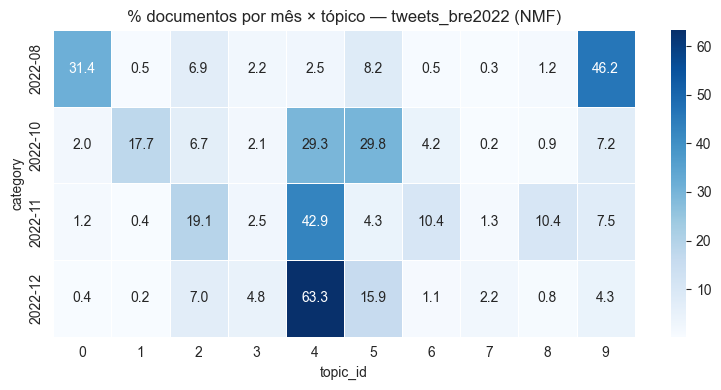

In [26]:
# Heatmap tópico × mês — tweets (category = YYYY-MM; deriva da data se ausente)
df_topic = df.copy()
if 'category' not in df_topic.columns and 'data' in df_topic.columns:
    df_topic['category'] = pd.to_datetime(df_topic['data'], errors='coerce').dt.to_period('M').astype(str)
if 'category' in df_topic.columns:
    df_topic = df_topic[['category']].assign(topic_id=dominant)
    df_topic = df_topic[df_topic['topic_id'] != -1]
    pivot = df_topic.groupby(['category', 'topic_id']).size().unstack(fill_value=0)
    pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
    import seaborn as sns
    fig, ax = plt.subplots(figsize=(max(8, len(pivot.columns)*0.8), max(4, len(pivot)*0.5)))
    sns.heatmap(pivot_pct.round(1), annot=True, fmt='.1f', cmap='Blues', linewidths=0.5, ax=ax)
    ax.set_title('% documentos por mês × tópico — tweets_bre2022 (NMF)')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'nmf_topic_category.png', dpi=150)
    print(f"Salvo: {OUTPUT_DIR / 'nmf_topic_category.png'}")
    plt.show()
else:
    print('Sem coluna category/data — cross-tab pulado')


## 11. Cross-tab tópico × mês

`category` é o mês de coleta (proxy temporal eleitoral, não rótulo de assunto). Esse cross-tab
mostra a evolução do discurso por tópico ao longo da janela eleitoral — não é validação de
ground-truth temática (não existe tal ground-truth neste corpus), mas uma checagem de
consistência temporal.


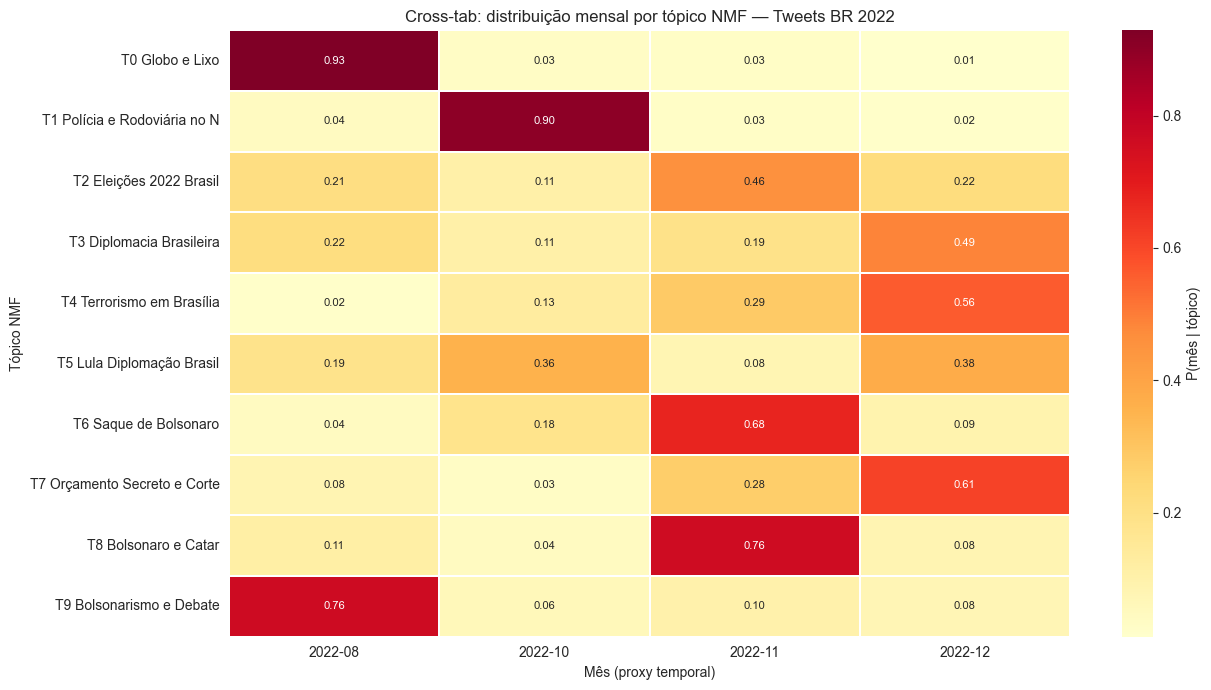

In [27]:
# Cell 20 — Heatmap topic x mes
df_topic = df[["category"]].copy()
df_topic["topic_id"] = dominant
df_topic["topic_name"] = [names[t] for t in dominant]

# Todos os meses (poucas categorias unicas, sem necessidade de filtrar top-N)
top_cats = sorted(df["category"].unique().tolist())
df_filt = df_topic[df_topic["category"].isin(top_cats)]

ct = pd.crosstab(df_filt["topic_id"], df_filt["category"], normalize="index")
ct = ct[top_cats]  # mantem ordem cronologica
ct.index = [f"T{i} {names[i][:25]}" for i in ct.index]

fig, ax = plt.subplots(figsize=(13, 0.5*len(ct) + 2))
sns.heatmap(ct, annot=True, fmt=".2f", cmap="YlOrRd", cbar_kws={"label": "P(mês | tópico)"},
            linewidths=0.3, ax=ax, annot_kws={"fontsize": 8})
ax.set_xlabel("Mês (proxy temporal)"); ax.set_ylabel("Tópico NMF")
ax.set_title("Cross-tab: distribuição mensal por tópico NMF — Tweets BR 2022")
plt.tight_layout(); plt.show()


## Evolução temporal dos tópicos

Participação média (θ) de cada tópico por mês (`category`, proxy temporal
eleitoral) — mostra picos e declínio de cada tema ao longo da janela 2022.

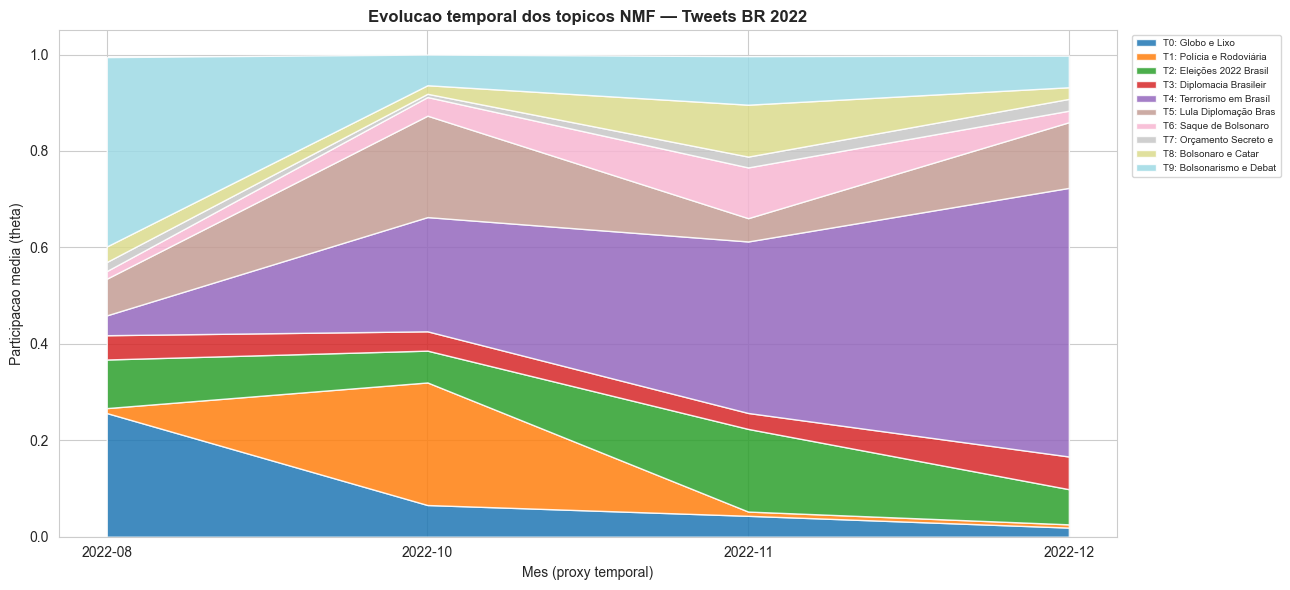

Salvo: ..\data\output\tweets_bre2022\nmf\tweets_bre2022_20260824_230336\nmf_topics_over_time.png


In [28]:
# Evolucao temporal dos topicos (tweets: category = mes de coleta, proxy temporal)
_theta_time = np.array(full)  # (n_docs, K)
_df_time = pd.DataFrame(_theta_time, columns=[f"T{tid}" for tid in range(BEST_K)])
_df_time["month"] = df["category"].values
_monthly_share = _df_time.groupby("month").mean()
_monthly_share = _monthly_share.reindex(sorted(_monthly_share.index))  # ordem cronologica

fig, ax = plt.subplots(figsize=(13, 6))
_cmap_time = plt.get_cmap("tab20", max(BEST_K, 1))
ax.stackplot(_monthly_share.index.astype(str), [_monthly_share[f"T{tid}"] for tid in range(BEST_K)],
             labels=[f"T{tid}: {names[tid][:20]}" for tid in range(BEST_K)],
             colors=[_cmap_time(tid) for tid in range(BEST_K)], alpha=0.85)
ax.set_xlabel("Mes (proxy temporal)"); ax.set_ylabel("Participacao media (theta)")
ax.set_title("Evolucao temporal dos topicos NMF — Tweets BR 2022", fontsize=12, fontweight="bold")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=7, ncol=1)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "nmf_topics_over_time.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Salvo: {OUTPUT_DIR / 'nmf_topics_over_time.png'}")

## pyLDAvis — visualização interativa (API genérica)

O adapter `pyLDAvis.gensim_models` exige o *state* Dirichlet do `LdaModel`
(inferência variacional) — o `gensim.models.Nmf` não o implementa. Usamos a
API genérica `pyLDAvis.prepare()`, que aceita `φ` (tópico×palavra) e `θ`
(doc×tópico) como matrizes cruas: exatamente o dado que o adapter do LDA
calcula por baixo dos panos. Mesma leitura de `02_lda_folha.ipynb`:

- **Esquerda**: tópicos como círculos no plano 2D (PCoA). Tamanho = prevalência,
  distância = dissimilaridade.
- **Direita**: bar chart das top-30 palavras do tópico selecionado, com slider
  λ controlando "exclusivity vs frequency" (Bischof & Airoldi 2016).

In [29]:
# pyLDAvis (API generica, interativo, salva HTML)
import pyLDAvis

pyLDAvis.enable_notebook()

print("Preparing pyLDAvis (API generica, ~30s)...")
_phi_vis = model.get_topics()  # (K, vocab_size)
_phi_vis = _phi_vis / _phi_vis.sum(axis=1, keepdims=True)  # garante soma=1 por linha

_theta_vis = np.array(full)  # (n_docs, K)
_zero_rows = _theta_vis.sum(axis=1) == 0
if _zero_rows.any():
    # docs sem massa de topico (raro, corpus muito esparso): fallback uniforme
    # para nao violar a validacao de pyLDAvis (cada linha de theta deve somar 1)
    _theta_vis[_zero_rows] = 1.0 / _theta_vis.shape[1]
_theta_vis = _theta_vis / _theta_vis.sum(axis=1, keepdims=True)

_doc_lengths = np.array([sum(cnt for _, cnt in bow) for bow in corpus_bow])
_vocab_vis = [dictionary[i] for i in range(len(dictionary))]
_term_freq = np.zeros(len(dictionary))
for bow in corpus_bow:
    for wid, cnt in bow:
        _term_freq[wid] += cnt

vis_data = pyLDAvis.prepare(
    topic_term_dists=_phi_vis,
    doc_topic_dists=_theta_vis,
    doc_lengths=_doc_lengths,
    vocab=_vocab_vis,
    term_frequency=_term_freq,
    sort_topics=False,
)
out_html = f"{out_dir}/nmf_pyldavis_K{BEST_K}.html"
pyLDAvis.save_html(vis_data, out_html)
print(f"Salvo: {out_html}")
vis_data

Preparing pyLDAvis (API generica, ~30s)...


D:\Área de Trabalho\UPE\1 Período\PLN\Topic Modeling - LDA and BERTopic\venv\Lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning:

divide by zero encountered in log

D:\Área de Trabalho\UPE\1 Período\PLN\Topic Modeling - LDA and BERTopic\venv\Lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning:

divide by zero encountered in log

D:\Área de Trabalho\UPE\1 Período\PLN\Topic Modeling - LDA and BERTopic\venv\Lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning:

divide by zero encountered in log



Salvo: ..\data\output\tweets_bre2022\nmf\tweets_bre2022_20260824_230336/nmf_pyldavis_K10.html


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0      0.005303 -0.197727       1        1   7.453153
1      0.364866  0.133477       2        1   4.665090
2     -0.120856  0.076334       3        1  10.564165
3      0.039477 -0.155345       4        1   5.691711
4      0.114498 -0.023647       5        1  34.007497
5      0.027987 -0.048786       6        1  10.557583
6     -0.078564  0.259938       7        1   4.389162
7     -0.123330  0.069287       8        1   2.072586
8     -0.177166  0.041478       9        1   4.888130
9     -0.052214 -0.155009      10        1  15.710924, topic_info=           Term         Freq        Total Category  logprob  loglift
29    bolsonaro  2619.000000  2619.000000  Default  30.0000  30.0000
87         lula  1869.000000  1869.000000  Default  29.0000  29.0000
30       brasil  1204.000000  1204.000000  Default  28.0000  28.0000
47   presidente  1010.000000  1010.000000  Default  27.0000  27.0000
330        jair   850.000000   850.000000  Default  26.0000  26.0000
..          ...          ...          ...      ...      ...      ...
251         ano    70.735676   199.572179  Topic10  -5.2080   0.8136
84      verdade    64.611037   132.579166  Topic10  -5.2986   1.1320
35     ministro    67.824322   265.486361  Topic10  -5.2500   0.4862
135         tar    65.528704   173.488417  Topic10  -5.2844   0.8772
194       ficar    66.188965   231.828507  Topic10  -5.2744   0.5973

[652 rows x 6 columns], token_table=      Topic      Freq      Term
term                           
560       1  0.213597  abençoar
560       2  0.071199  abençoar
560       4  0.569591  abençoar
560       6  0.071199  abençoar
560       7  0.071199  abençoar
...     ...       ...       ...
515       6  0.294082      ódio
515       7  0.015478      ódio
515      10  0.030956      ódio
1616      3  0.067622    ônibus
1616      5  0.928907    ônibus

[1805 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

## Top documentos por tópico

Mostra os 3 docs com maior probabilidade em cada tópico — verificação qualitativa direta da semântica.


In [30]:
# Cell 22 — Top 3 docs por topico
TOP_N_DOCS = 3
TRUNC = 200

theta_arr = np.array(full)
print("Top docs por topico (truncados em 200 chars):\n")
for tid in sorted(topics_keywords):
    top_idx = np.argsort(theta_arr[:, tid])[::-1][:TOP_N_DOCS]
    print(f"=== T{tid} [{names[tid]}] ===")
    print(f"  keywords: {topics_keywords[tid][:8]}\n")
    for rank, idx in enumerate(top_idx, 1):
        prob = theta_arr[idx, tid]
        cat = df.iloc[idx]["category"]
        text = df.iloc[idx]["message"][:TRUNC].replace("\n", " ")
        print(f"  #{rank} (P={prob:.3f}, cat={cat}): {text}...")
        print()


Top docs por topico (truncados em 200 chars):

=== T0 [Globo e Lixo] ===
  keywords: ['globolixo', 'hoje', 'dia', 'casa', 'globo', 'falar', 'entrevista', 'puder']

  #1 (P=1.000, cat=2022-08): Assistam … Extremamente RELEVANTE !! A #GloboLixo foi SÓRDIDA e HEDIONDA … sem perdão !! https://t.co/8kmjNIuU4b...

  #2 (P=1.000, cat=2022-08): @rmotta2 #GloboLixo ! Jornalismo sujo demais !!...

  #3 (P=1.000, cat=2022-08): @leandroruschel @Betoa7Alves Tamu junto Fique em casa se puder #GloboLixo...

=== T1 [Polícia e Rodoviária no Nordeste] ===
  keywords: ['votar', 'nordeste', 'deixem', 'federal', 'polícia', 'rodoviária', 'lulapresidente', 'impedir']

  #1 (P=1.000, cat=2022-10): DEIXEM O NORDESTE VOTAR https://t.co/r2yCUCODCa...

  #2 (P=1.000, cat=2022-10): DEIXEM O NORDESTE VOTAR! DEIXEM O NORDESTE VOTAR! DEIXEM O NORDESTE VOTAR! DEIXEM O NORDESTE VOTAR! DEIXEM O NORDESTE VOTAR! DEIXEM O NORDESTE VOTAR! DEIXEM O NORDESTE VOTAR! DEIXEM O NORDESTE VOTAR! ...

  #3 (P=1.000, cat=2022-10): Po

## 12. Export + relatório qualitativo

Gera os CSVs canônicos (`nmf_results.csv`, `nmf_topics_for_eval.csv`, `nmf_metrics.csv`).


In [31]:
# Cell 23 — Export final
os.makedirs(out_dir, exist_ok=True)

export_results(
    topics=dominant, probs=full, names=names, texts=docs,
    output_path=f"{out_dir}/nmf_results.csv",
    topic_type="probabilistic", granularity="unit", post_ids=post_ids,
)
export_topics_for_eval(
    topics_keywords=topics_keywords, topics_names=names,
    model_name="nmf", output_path=f"{out_dir}/nmf_topics_for_eval.csv",
)
metrics_full = {**metrics, "k_grid_scores": json.dumps(scores),
                "k_npmi_scores": json.dumps(npmi_scores),
                # curva de Diversity sobre a faixa de K — segundo eixo da fronteira
                # de Pareto do protocolo 2026-08-22/23 (secao 1.6).
                "k_diversity_scores": json.dumps(div_scores),
                "reconstruction_error": reconstruction_error, "grid_passes": 20,
                "best_kappa": best_kappa, "best_min_prob": best_min_prob,
                "corpus_version": _corpus_dir.name}
pd.DataFrame([metrics_full]).to_csv(f"{out_dir}/nmf_metrics.csv", index=False)
# Cache no diretorio-BASE nmf/ (reutilizado em runs futuros sem re-rodar grid)
pd.DataFrame([metrics_full]).to_csv(f"{BASE_OUTPUT_DIR}/nmf_metrics.csv", index=False)

print(f"CSVs em {out_dir}/:")
for f in ["nmf_results.csv", "nmf_topics_for_eval.csv", "nmf_metrics.csv"]:
    sz = os.path.getsize(f"{out_dir}/{f}")
    print(f"  {f} ({sz/1024:.0f} KB)")
print(f"\nVersao do corpus: {_corpus_dir.name}")

# Matriz beta completa (tópico × vocabulário) — habilita retrofits sem refit
_beta = model.get_topics()  # (K, vocab_size)
_vocab = [dictionary[i] for i in range(len(dictionary))]
pd.DataFrame(_beta, columns=_vocab).to_csv(f"{out_dir}/nmf_beta.csv", index_label="topic_id")
print(f"Salvo: {out_dir}/nmf_beta.csv ({_beta.shape[0]}x{_beta.shape[1]})")


CSVs em ..\data\output\tweets_bre2022\nmf\tweets_bre2022_20260824_230336/:
  nmf_results.csv (3064 KB)
  nmf_topics_for_eval.csv (1 KB)
  nmf_metrics.csv (1 KB)

Versao do corpus: tweets_bre2022_20260629_215159
Salvo: ..\data\output\tweets_bre2022\nmf\tweets_bre2022_20260824_230336/nmf_beta.csv (10x2617)


In [32]:
# Cell 24 — Exclusividade + n_docs por tópico (ranking p/ o assessor de calibração)
# Espelha o bertopic_exclusividade_ranking.csv. Reusa os MESMOS topic_word_scores
# nativos (phi/beta) do cálculo de exclusividade do nmf_metrics.csv, p/ o ranking
# BATER com as métricas (mesma convenção do BERTopic). Coletado pelo advisor via
# glob *exclusividade_ranking.csv.
from _helpers import export_exclusividade_ranking

excl_rank_df = export_exclusividade_ranking(
    topics_keywords=topics_keywords,
    dominant_per_doc=dominant,
    names=names,
    topic_word_scores=_topic_word_scores_nmf,
    out_path=f"{out_dir}/nmf_exclusividade_ranking.csv",
    top_n=params["evaluation"].get("top_n_keywords_metrics", 20),
)
print("nmf_exclusividade_ranking.csv (exclusividade desc):")
print(excl_rank_df.to_string(index=False))

nmf_exclusividade_ranking.csv (exclusividade desc):
 topic_id                       topic_name  exclusividade  n_docs
        1 Polícia e Rodoviária no Nordeste       0.757177     270
        8                Bolsonaro e Catar       0.692825     283
        3            Diplomacia Brasileira       0.688091     269
        9            Bolsonarismo e Debate       0.669759    1586
        6               Saque de Bolsonaro       0.660308     317
        4           Terrorismo em Brasília       0.627711    3090
        0                     Globo e Lixo       0.585401     885
        7        Orçamento Secreto e Corte       0.569425      98
        2             Eleições 2022 Brasil       0.426901     860
        5           Lula Diplomação Brasil       0.395056    1153


In [33]:
# Cell 24 — Relatorio qualitativo (template)
md = qualitative_report(topics_keywords, names)
print(md)


# Qualitative report
**Total topics:** 10
## Tópicos coesos
_(preencher manualmente: tópicos com keywords semanticamente próximas e tema único)_
## Tópicos genéricos / discurso
_(preencher manualmente: keywords genéricas, sem tema concreto)_
## Tópicos lixo / boilerplate
_(preencher manualmente: keywords são fórmulas, hashtags, headers, etc.)_
## Redundâncias
_(preencher manualmente: tópicos diferentes que cobrem o mesmo tema)_
## Candidatos a stop word
_(preencher manualmente: termos repetidos em 3+ tópicos sem agregar diferenciação)_
## Tabela de tópicos
| ID | Nome | Top keywords |
|---|---|---|
| T0 | Globo e Lixo | globolixo, hoje, dia, casa, globo, falar, entrevista, puder, fique, bonner |
| T1 | Polícia e Rodoviária no Nordeste | votar, nordeste, deixem, federal, polícia, rodoviária, lulapresidente, impedir, prf, golpe |
| T2 | Eleições 2022 Brasil | bolsonaro, cadeia, lula, voto, acabar, bolsonaroreeleito, trabalha, deixar, sirene, rombo |
| T3 | Diplomacia Brasileira | preside

## Próximos passos

- Comparar com LDA (`02_lda_tweets_bre2022.ipynb`) e BERTopic (`01_bertopic_tweets_bre2022.ipynb`) — triangulação LDA × NMF × BERTopic
- Validar empiricamente H2 comparando `coherence_cv_recomputed` deste notebook com Folha
- Analisar evolução temporal de tópicos usando `category` (mês) como proxy eleitoral

## Referências

- Lee, D. D., Seung, H. S. (1999). *Learning the parts of objects by non-negative matrix factorization*. Nature.
- Roder, M., Both, A., Hinneburg, A. (2015). *Exploring the Space of Topic Coherence Measures*. WSDM — c_v.
- Stevens, K. et al. (2012). *Exploring topic coherence over many models and many topics*. EMNLP — limitações de c_v com K alto.
- Dieng, A. B., Ruiz, F. J. R., Blei, D. M. (2020). *Topic Modeling in Embedding Spaces*. TACL — Topic Diversity.
